#### Libraries and Global Settings

In [10]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Portable font setting for GitHub/Jupyter environments
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global plotting style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",
    "axes.facecolor"   : "#243558",
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",
    "axes.titlecolor"  : "#FFFFFF",
    "xtick.color"      : "#FFFFFF",
    "ytick.color"      : "#FFFFFF",
    "text.color"       : "#FFFFFF",
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Common colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"
BG_COLOR = rcParams["figure.facecolor"]

TIMING_COLORS = {
    "Pre-market": C_BEFORE,
    "Intraday": C_DURING,
    "After-hours": C_AFTER,
}


# 13. Industry-Level Analysis

Industries are classified using Korean Standard Industrial Classification (KSIC) codes obtained from the Financial Supervisory Service's DART Company Overview API.

In [ ]:
# ================================================================
# Industry Classification Using DART Company Overview API
# ================================================================

import time
import requests
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DATA_DIR = Path("../data_collection")

SECTOR_MAP_PATH = DATA_DIR / "krx_sector_map.csv"

DART_API_KEY = os.getenv("DART_API_KEY")


# ------------------------------------------------------------
# 1. Load company data
# ------------------------------------------------------------

comp = pd.read_csv(
    DATA_DIR / "company_krx_fdr_controls_2019_2026.csv",
    dtype=str
)


# ------------------------------------------------------------
# 2. Standardize identifiers
# ------------------------------------------------------------

comp["stock_code"] = (
    comp["stock_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

comp["corp_code"] = (
    comp["corp_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(8)
)


print(
    f"Number of firms loaded: "
    f"{len(comp):,}"
)


# ------------------------------------------------------------
# 3. Map the first two digits of KSIC codes
#    into research-specific industry sectors
# ------------------------------------------------------------

INDUTY_MAP = {
    "10": "Consumer",
    "11": "Consumer",
    "12": "Consumer",
    "13": "Chemicals/Materials",
    "14": "Consumer",
    "15": "Consumer",
    "16": "Chemicals/Materials",
    "17": "Chemicals/Materials",
    "18": "Consumer",
    "19": "Energy",

    "20": "Chemicals/Materials",
    "21": "Biotech/Healthcare",
    "22": "Chemicals/Materials",
    "23": "Chemicals/Materials",
    "24": "Chemicals/Materials",
    "25": "Machinery/Transportation",
    "26": "IT/Electronics",
    "27": "IT/Electronics",
    "28": "Machinery/Transportation",
    "29": "Machinery/Transportation",
    "30": "Machinery/Transportation",
    "31": "Machinery/Transportation",
    "32": "IT/Electronics",
    "33": "Machinery/Transportation",

    "35": "Energy",
    "36": "Energy",
    "37": "Energy",
    "38": "Energy",
    "39": "Energy",

    "41": "Construction",
    "42": "Construction",

    "45": "Machinery/Transportation",
    "46": "Consumer",
    "47": "Consumer",

    "49": "Machinery/Transportation",
    "50": "Machinery/Transportation",
    "51": "Machinery/Transportation",
    "52": "Machinery/Transportation",

    "58": "IT/Electronics",
    "59": "Services",
    "60": "Services",
    "61": "IT/Electronics",
    "62": "IT/Electronics",
    "63": "IT/Electronics",

    "64": "Finance",
    "65": "Finance",
    "66": "Finance",

    "68": "Construction",

    "70": "Services",
    "71": "Services",
    "72": "Biotech/Healthcare",
    "73": "Services",
    "74": "Services",

    "86": "Biotech/Healthcare",
    "87": "Biotech/Healthcare",
    "88": "Biotech/Healthcare",

    "90": "Services",
    "91": "Services",
    "92": "Services",
}


# ------------------------------------------------------------
# 4. Retrieve KSIC industry code from DART
#    with automatic retry for temporary network errors
# ------------------------------------------------------------

def get_induty(
    corp_code,
    api_key,
    max_retries=5
):
    """
    Retrieve the KSIC industry code from the DART Company Overview API
    and map it to a research-specific industry sector.

    Temporary network errors are retried automatically.
    """

    url = "https://opendart.fss.or.kr/api/company.json"

    for attempt in range(
        1,
        max_retries + 1
    ):

        try:

            response = requests.get(
                url,
                params={
                    "crtfc_key": api_key,
                    "corp_code": corp_code,
                },
                timeout=15,
            )

            response.raise_for_status()

            data = response.json()


            # ------------------------------------------------
            # Successful DART API response
            # ------------------------------------------------

            if data.get("status") == "000":

                code = str(
                    data.get(
                        "induty_code",
                        ""
                    )
                ).strip()

                # API call succeeded but no KSIC code was returned
                if not code:

                    return (
                        "",
                        "Other",
                        "MISSING_INDUTY_CODE"
                    )


                sector = INDUTY_MAP.get(
                    code[:2],
                    "Other"
                )

                return (
                    code,
                    sector,
                    "000"
                )


            # ------------------------------------------------
            # Valid DART response with non-success status
            # ------------------------------------------------

            return (
                "",
                "Other",
                f"DART_STATUS_{data.get('status', 'UNKNOWN')}"
            )


        # ----------------------------------------------------
        # Temporary network errors -> retry
        # ----------------------------------------------------

        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.Timeout,
            requests.exceptions.SSLError,
        ) as exc:

            if attempt < max_retries:

                wait_seconds = (
                    attempt * 2
                )

                print(
                    f"Temporary API error for corp_code "
                    f"{corp_code} "
                    f"({type(exc).__name__}). "
                    f"Retrying in "
                    f"{wait_seconds}s "
                    f"[{attempt}/{max_retries}]..."
                )

                time.sleep(
                    wait_seconds
                )

            else:

                return (
                    "",
                    "Other",
                    (
                        "REQUEST_ERROR_AFTER_RETRIES: "
                        f"{type(exc).__name__}"
                    )
                )


        # ----------------------------------------------------
        # Other request-related errors
        # ----------------------------------------------------

        except requests.RequestException as exc:

            return (
                "",
                "Other",
                (
                    "REQUEST_ERROR: "
                    f"{type(exc).__name__}"
                )
            )


        # ----------------------------------------------------
        # Other unexpected errors
        # ----------------------------------------------------

        except Exception as exc:

            return (
                "",
                "Other",
                (
                    "ERROR: "
                    f"{type(exc).__name__}"
                )
            )


# ------------------------------------------------------------
# 5. Retrieve industry classifications for all firms
# ------------------------------------------------------------

records = []

status_counts = {}

total_firms = len(comp)


for i, row in comp.iterrows():

    induty_code, sector, status = get_induty(
        row["corp_code"],
        DART_API_KEY,
        max_retries=5
    )


    records.append({
        "stock_code": row["stock_code"],
        "corp_code": row["corp_code"],
        "corp_name": row["corp_name"],
        "induty_code": induty_code,
        "sector": sector,
    })


    status_counts[status] = (
        status_counts.get(
            status,
            0
        )
        + 1
    )


    if (i + 1) % 50 == 0:

        print(
            f"{i + 1:,}/"
            f"{total_firms:,} "
            f"firms processed..."
        )


    # Small delay between requests
    time.sleep(0.15)


# ------------------------------------------------------------
# 6. Create industry mapping DataFrame
# ------------------------------------------------------------

df_sector = pd.DataFrame(
    records
)


# ------------------------------------------------------------
# 7. Diagnostics
# ------------------------------------------------------------

print(
    "\n=== DART API Status ==="
)


for status, count in sorted(
    status_counts.items(),
    key=lambda x: -x[1]
):

    print(
        f"{status}: "
        f"{count:,}"
    )


# ------------------------------------------------------------
# Check whether KSIC industry codes were retrieved
# ------------------------------------------------------------

valid_industry = (
    df_sector["induty_code"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)


retrieved_count = (
    valid_industry.sum()
)

retrieval_rate = (
    valid_industry.mean()
    * 100
)


print(
    f"\nKSIC codes retrieved: "
    f"{retrieved_count:,} / "
    f"{len(df_sector):,}"
)

print(
    f"Retrieval rate: "
    f"{retrieval_rate:.1f}%"
)


# ------------------------------------------------------------
# 8. Display sector distribution
# ------------------------------------------------------------

print(
    "\n=== Number of Firms by Industry Sector ==="
)

print(
    df_sector["sector"]
    .value_counts(
        dropna=False
    )
)


print(
    "\n=== Sample Classification ==="
)

print(
    df_sector[
        [
            "stock_code",
            "corp_name",
            "induty_code",
            "sector",
        ]
    ]
    .head(20)
    .to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 9. Identify remaining failed API requests
# ------------------------------------------------------------

failure_mask = (
    df_sector["induty_code"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)


failed_firms = (
    df_sector[
        failure_mask
    ]
    .copy()
)


if len(failed_firms) > 0:

    print(
        "\n=== Firms with Missing KSIC Codes ==="
    )

    print(
        failed_firms[
            [
                "stock_code",
                "corp_code",
                "corp_name",
                "sector",
            ]
        ]
        .to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# 10. Check for request failures
#
# MISSING_INDUTY_CODE is treated separately because the API
# request itself succeeded.
# ------------------------------------------------------------

request_failure_count = sum(
    count
    for status, count
    in status_counts.items()
    if (
        status.startswith("REQUEST_ERROR")
        or status.startswith("ERROR:")
    )
)


dart_failure_count = sum(
    count
    for status, count
    in status_counts.items()
    if status.startswith(
        "DART_STATUS_"
    )
)


missing_code_count = (
    status_counts.get(
        "MISSING_INDUTY_CODE",
        0
    )
)


print(
    "\n=== Final Retrieval Diagnostics ==="
)

print(
    f"Successful API responses: "
    f"{status_counts.get('000', 0):,}"
)

print(
    f"Missing KSIC codes in successful responses: "
    f"{missing_code_count:,}"
)

print(
    f"Request failures after retries: "
    f"{request_failure_count:,}"
)

print(
    f"DART non-success responses: "
    f"{dart_failure_count:,}"
)


# ------------------------------------------------------------
# 11. Safety check
#
# Do not overwrite the mapping file if temporary API/request
# failures remain after all retries.
# ------------------------------------------------------------

if request_failure_count > 0:

    raise RuntimeError(
        "Some DART API requests still failed after all retries. "
        "The industry mapping file was NOT overwritten. "
        "Re-run this cell when the network connection is stable."
    )


if dart_failure_count > 0:

    raise RuntimeError(
        "DART returned one or more non-success API statuses. "
        "The industry mapping file was NOT overwritten. "
        "Review the API status codes before proceeding."
    )


# ------------------------------------------------------------
# 12. Additional coverage check
# ------------------------------------------------------------

if valid_industry.mean() < 0.90:

    raise RuntimeError(
        "Too many KSIC industry codes are missing. "
        "The industry mapping file was NOT overwritten."
    )


# ------------------------------------------------------------
# 13. Save industry classification data
# ------------------------------------------------------------

df_sector.to_csv(
    SECTOR_MAP_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    f"\nSaved: "
    f"{SECTOR_MAP_PATH}"
)

print(
    f"Completed: "
    f"{len(df_sector):,} firms"
)

Number of firms loaded: 947
50/947 firms processed...
100/947 firms processed...
150/947 firms processed...
200/947 firms processed...
250/947 firms processed...
300/947 firms processed...
350/947 firms processed...
400/947 firms processed...
450/947 firms processed...
500/947 firms processed...
550/947 firms processed...
600/947 firms processed...
650/947 firms processed...
700/947 firms processed...
750/947 firms processed...
800/947 firms processed...
850/947 firms processed...
900/947 firms processed...

=== DART API Status ===
000: 947

KSIC codes retrieved: 947 / 947
Retrieval rate: 100.0%

=== Number of Firms by Industry Sector ===
sector
IT/Electronics              262
Machinery/Transportation    182
Chemicals/Materials         131
Consumer                     91
Finance                      85
Biotech/Healthcare           83
Services                     55
Other                        24
Construction                 24
Energy                       10
Name: count, dtype: int64


In [2]:
# ================================================================
# CELL 1: Imports and Industry Color Palette
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

SECTOR_COLORS = {
    "IT/Electronics": "#4C72B0",
    "Biotech/Healthcare": "#1D9E75",
    "Finance": "#8172B3",
    "Chemicals/Materials": "#CCB974",
    "Machinery/Transportation": "#64B5CD",
    "Construction": "#C44E52",
    "Energy": "#937860",
    "Consumer": "#DA8EC0",
    "Services": "#DD8452",
    "Other": "#AAAAAA",
}


In [3]:
# ================================================================
# CELL 2: Load Data
# ================================================================

DATA_DIR = Path("../data_collection")

raw_fin = pd.read_csv(
    DATA_DIR / "dart_earnings_financials_2019_2026.csv",
    dtype=str
)
raw_ctrl = pd.read_csv(
    DATA_DIR / "dart_financial_controls_2019_2025.csv"
)
raw_comp = pd.read_csv(
    DATA_DIR / "company_krx_fdr_controls_2019_2026.csv",
    dtype=str
)
raw_time = pd.read_csv(
    DATA_DIR / "dart_earnings_time_2019_2026.csv",
    dtype=str
)
raw_price = pd.read_csv(
    DATA_DIR / "stock_price_2018_2026.csv",
    dtype={"stock_code": str}
)

print(f"Disclosure timing rows: {len(raw_time):,}")
print(
    f"Stock-price rows: {len(raw_price):,} | "
    f"Number of stocks: {raw_price['stock_code'].nunique():,}"
)


Disclosure timing rows: 16,218
Stock-price rows: 1,657,925 | Number of stocks: 947


In [4]:
# ================================================================
# CELL 3: Stock-Price Preprocessing for gap_ret
# ================================================================

price = raw_price.copy()

price["date"] = pd.to_datetime(price["date"])
price["open"] = pd.to_numeric(price["open"], errors="coerce")
price["close"] = pd.to_numeric(price["close"], errors="coerce")

price.loc[price["open"] == 0, "open"] = np.nan
price.loc[price["close"] == 0, "close"] = np.nan

price = price.sort_values(["stock_code", "date"])

price["prev_close"] = (
    price.groupby("stock_code")["close"].shift(1)
)
price["next_open"] = (
    price.groupby("stock_code")["open"].shift(-1)
)
price["intraday_ret"] = (
    price["close"] / price["open"] - 1
)

print("Stock-price preprocessing completed.")
print(
    "Zero opening prices replaced with NaN: "
    f"{(pd.to_numeric(raw_price['open'], errors='coerce') == 0).sum():,}"
)


Stock-price preprocessing completed.
Zero opening prices replaced with NaN: 17,179


In [5]:
# ================================================================
# CELL 4: Classify Disclosure Timing, Merge Prices, and Calculate gap_ret
# ================================================================

time_df = raw_time.copy()

time_df["rcept_dt"] = pd.to_datetime(
    time_df["rcept_dt"],
    format="%Y%m%d"
)

t = time_df["rcept_time"].str.split(":", expand=True)
time_df["_h"] = pd.to_numeric(t[0], errors="coerce")
time_df["_m"] = pd.to_numeric(t[1], errors="coerce")

time_df["timing"] = "Intraday"

time_df.loc[
    time_df["_h"] < 9,
    "timing"
] = "Pre-market"

time_df.loc[
    (time_df["_h"] > 15)
    | (
        (time_df["_h"] == 15)
        & (time_df["_m"] > 30)
    ),
    "timing"
] = "After-hours"

time_df.loc[
    time_df["_h"].isna(),
    "timing"
] = None

time_df.drop(
    columns=["_h", "_m"],
    inplace=True
)

time_df["weekday"] = time_df["rcept_dt"].dt.dayofweek
time_df["year"] = time_df["rcept_dt"].dt.year

merged = time_df.merge(
    price[
        [
            "date",
            "stock_code",
            "open",
            "close",
            "prev_close",
            "next_open",
            "intraday_ret",
        ]
    ],
    left_on=["rcept_dt", "stock_code"],
    right_on=["date", "stock_code"],
    how="left",
)

# Return definition by disclosure timing:
# After-hours: disclosure-day close -> next trading-day open
# Pre-market: previous trading-day close -> disclosure-day open
# Intraday: disclosure-day open -> disclosure-day close
merged["gap_ret"] = np.where(
    merged["timing"] == "After-hours",
    merged["next_open"] / merged["close"] - 1,
    np.where(
        merged["timing"] == "Pre-market",
        merged["open"] / merged["prev_close"] - 1,
        merged["intraday_ret"],
    ),
)

print("Disclosure-timing classification completed.")
print(merged["timing"].value_counts())

print(
    f"\nMissing gap_ret observations: "
    f"{merged['gap_ret'].isna().sum():,}"
)


Disclosure-timing classification completed.
timing
Intraday       8370
After-hours    6728
Pre-market     1098
Name: count, dtype: int64

Missing gap_ret observations: 97


In [6]:
# ================================================================
# CELL 5: Classify Good/Bad News, Filter Disclosures, and Build df_hb
# ================================================================

fin_oi = (
    raw_fin[
        ["rcept_no", "operating_income_won"]
    ]
    .drop_duplicates("rcept_no")
    .copy()
)

fin_oi["oi_won"] = pd.to_numeric(
    fin_oi["operating_income_won"],
    errors="coerce"
)

merged = merged.merge(
    fin_oi[["rcept_no", "oi_won"]],
    on="rcept_no",
    how="left"
)

merged = merged.sort_values(
    ["stock_code", "rcept_dt"]
)

merged["prev_oi"] = (
    merged.groupby("stock_code")["oi_won"].shift(1)
)

merged["oi_chg_pct"] = np.where(
    merged["prev_oi"].notna()
    & (merged["prev_oi"] != 0),
    (
        merged["oi_won"] - merged["prev_oi"]
    )
    / merged["prev_oi"].abs(),
    np.nan,
)

merged["news"] = np.select(
    [
        merged["oi_chg_pct"] > 0.10,
        merged["oi_chg_pct"] < -0.10,
        merged["oi_chg_pct"].between(
            -0.10,
            0.10,
            inclusive="both"
        ),
    ],
    [
        "Good News",
        "Bad News",
        "Neutral",
    ],
    default="Missing",
)

# Korean report-name strings below are source-data literals and therefore
# intentionally remain unchanged.
remove = merged["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly",
    na=False,
    regex=True,
)

merged = merged[~remove].copy()
merged = merged[merged["year"] <= 2025].copy()

# "연결" is retained because it is a literal value in Korean DART report names.
merged["is_consolidated"] = (
    merged["report_nm"].str.contains(
        "연결",
        na=False
    )
)

merged = merged.sort_values(
    [
        "stock_code",
        "rcept_dt",
        "is_consolidated",
        "rcept_no",
    ],
    ascending=[True, True, False, True],
)

merged = merged.drop_duplicates(
    subset=["stock_code", "rcept_dt"],
    keep="first",
)

df = merged.copy()

df_hb = df[
    df["news"].isin(
        ["Good News", "Bad News"]
    )
    & df["timing"].notna()
].copy()

print(f"Final sample: {len(df_hb):,}")
print(
    f"Good News: {df_hb['news'].eq('Good News').sum():,} | "
    f"Bad News: {df_hb['news'].eq('Bad News').sum():,}"
)
print(
    f"Missing gap_ret observations: "
    f"{df_hb['gap_ret'].isna().sum():,}"
)

print("\nMean gap_ret (%) by news type and timing:")
print(
    (
        df_hb
        .groupby(["news", "timing"])["gap_ret"]
        .mean()
        * 100
    )
    .round(3)
    .unstack()
)


Final sample: 8,553
Good News: 4,517 | Bad News: 4,036
Missing gap_ret observations: 15

Mean gap_ret (%) by news type and timing:
timing     After-hours  Intraday  Pre-market
news                                        
Bad News        -0.524    -0.413       0.078
Good News        1.213     1.463       1.229


In [7]:
# ================================================================
# CELL 6: Merge Industry Classification
# ================================================================

SECTOR_MAP_PATH = DATA_DIR / "krx_sector_map.csv"


def load_krx_sector(path, comp_df):
    try:
        krx = pd.read_csv(path, dtype=str)

        krx["stock_code"] = (
            krx["stock_code"]
            .astype(str)
            .str.strip()
            .str.replace(r"\.0$", "", regex=True)
            .str.zfill(6)
        )

        comp_df = comp_df.copy()
        comp_df["stock_code"] = (
            comp_df["stock_code"]
            .astype(str)
            .str.strip()
            .str.replace(r"\.0$", "", regex=True)
            .str.zfill(6)
        )

        out = comp_df.merge(
            krx[
                [
                    "stock_code",
                    "induty_code",
                    "sector",
                ]
            ],
            on="stock_code",
            how="left",
        )

        out["sector"] = (
            out["sector"]
            .fillna("Other")
        )

        coverage = (
            out["sector"]
            .ne("Other")
            .mean()
            * 100
        )

        print(
            f"Industry mapping loaded "
            f"(classification coverage: {coverage:.1f}%)."
        )
        print(out["sector"].value_counts().to_string())

        return out

    except FileNotFoundError:
        print(
            "krx_sector_map.csv was not found. "
            "Running keyword-based fallback classification."
        )
        return _fallback_keyword_sector(comp_df)


def _fallback_keyword_sector(comp_df):
    # Korean keywords are intentionally retained because corp_name values
    # originate from Korean source data.
    RULES = {
        "IT/Electronics": [
            "전자", "반도체", "디스플레이", "통신", "텔레콤",
            "소프트웨어", "IT", "인터넷", "게임", "테크", "디지털",
            "AI", "NAVER", "카카오", "넥슨", "넷마블", "크래프톤",
            "칩스", "실리콘",
        ],
        "Biotech/Healthcare": [
            "바이오", "제약", "의료", "헬스", "약품", "생명",
            "메디", "파마", "치료", "진단", "셀트리온",
            "종근당", "유한", "녹십자",
        ],
        "Finance": [
            "금융", "은행", "증권", "보험", "투자", "캐피탈",
            "저축", "카드", "신탁", "자산운용", "파이낸스",
            "리츠", "다올",
        ],
        "Chemicals/Materials": [
            "화학", "케미칼", "소재", "플라스틱", "고무", "정유",
            "석유", "섬유", "도료", "비료", "LG화학", "SK이노",
            "롯데케미", "한화솔",
        ],
        "Machinery/Transportation": [
            "자동차", "모빌리티", "운송", "물류", "항공", "해운",
            "택배", "기계", "중공업", "조선", "만도", "현대위아",
        ],
        "Construction": [
            "건설", "건축", "토건", "주택", "부동산", "E&C",
            "엔지니어링", "개발", "GS건설", "대우건설", "HDC",
        ],
        "Energy": [
            "에너지", "전력", "가스", "발전", "원자력",
            "신재생", "태양광",
        ],
        "Consumer": [
            "유통", "리테일", "마트", "백화점", "홈쇼핑", "식품",
            "음료", "제과", "유제품", "화장품", "아모레",
            "이니스프리",
        ],
        "Services": [
            "광고", "미디어", "엔터", "방송", "영화", "콘텐츠",
            "여행", "호텔", "레저", "제일기획", "이노션",
        ],
    }

    def classify(name):
        for sector, keywords in RULES.items():
            for keyword in keywords:
                if keyword.lower() in str(name).lower():
                    return sector
        return "Other"

    out = comp_df.copy()
    out["sector"] = out["corp_name"].apply(classify)
    out["krx_sector"] = out["sector"]

    print(out["sector"].value_counts().to_string())

    return out


comp_with_sector = load_krx_sector(
    SECTOR_MAP_PATH,
    raw_comp
)

# Remove a pre-existing sector column, if any, before a fresh merge.
df_hb = df_hb.drop(
    columns=["sector"],
    errors="ignore"
)

df_hb["stock_code"] = (
    df_hb["stock_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

df_hb = df_hb.merge(
    comp_with_sector[
        [
            "stock_code",
            "sector",
            "log_marcap",
        ]
    ],
    on="stock_code",
    how="left",
)

df_hb["sector"] = (
    df_hb["sector"]
    .fillna("Other")
)

print("\n=== Industry Classification Check ===")
print(
    f"Classification Coverage: "
    f"{df_hb['sector'].ne('Other').mean() * 100:.1f}%"
)
print()
print(df_hb["sector"].value_counts())
print(
    f"\nNumber of Unique Industries: "
    f"{df_hb['sector'].nunique()}"
)


Industry mapping loaded (classification coverage: 97.5%).
sector
IT/Electronics              262
Machinery/Transportation    182
Chemicals/Materials         131
Consumer                     91
Finance                      85
Biotech/Healthcare           83
Services                     55
Other                        24
Construction                 24
Energy                       10

=== Industry Classification Check ===
Classification Coverage: 97.4%

sector
IT/Electronics              2206
Chemicals/Materials         1334
Machinery/Transportation    1252
Finance                      998
Consumer                     909
Biotech/Healthcare           834
Services                     444
Construction                 253
Other                        226
Energy                        97
Name: count, dtype: int64

Number of Unique Industries: 10


# 13. Industry-Level Analysis

This analysis reclassifies Korean listed firms into research-specific industry sectors using Korean Standard Industrial Classification (KSIC) codes obtained from the DART Company Overview API. It then examines whether after-hours disclosure patterns for negative earnings news differ systematically across industries.

The analysis proceeds in five stages:

1. **Comparison of After-Hours Bad-News Disclosure Rates across Industries** — chi-square tests
2. **Comparison of Market Impact across Industries** — Kruskal–Wallis test
3. **Bad-News Severity × Industry Cross-Analysis** — variation in timing patterns by severity
4. **Concentration of Firms with Repeated After-Hours Disclosures** — firm-level persistence versus broader industry patterns
5. **Downside-Risk Distribution and Integrated Risk Matrix** — combining disclosure frequency, market impact, persistence, and severity associations

Industry-classification coverage is approximately **97.5%**, and the analytical sample contains **8,553 good- and bad-news disclosures**.

In [8]:
# ================================================================
# CELL 7: Industry-Level After-Hours Rates and Chi-Square Tests
# ================================================================

from scipy.stats import chi2_contingency

MIN_BAD = 15

total_bad_after_pct = (
    df_hb[df_hb["news"] == "Bad News"]["timing"]
    .eq("After-hours")
    .mean()
    * 100
)

summary_rows = []

for sector in df_hb["sector"].value_counts().index:
    sub = df_hb[df_hb["sector"] == sector]

    bad = sub[sub["news"] == "Bad News"]
    good = sub[sub["news"] == "Good News"]

    if len(bad) < MIN_BAD:
        continue

    bad_after_pct = (
        bad["timing"]
        .eq("After-hours")
        .mean()
        * 100
    )

    good_after_pct = (
        good["timing"]
        .eq("After-hours")
        .mean()
        * 100
        if len(good) > 0
        else np.nan
    )

    diff = (
        bad_after_pct - good_after_pct
        if len(good) > 0
        else np.nan
    )

    # Within-industry chi-square test:
    # News Type (Good/Bad) × Disclosure Timing (Pre-market/Intraday/After-hours)
    ct = pd.crosstab(
        sub["news"],
        sub["timing"]
    )

    for col in [
        "Pre-market",
        "Intraday",
        "After-hours",
    ]:
        if col not in ct.columns:
            ct[col] = 0

    ct = ct[
        [
            "Pre-market",
            "Intraday",
            "After-hours",
        ]
    ]

    try:
        chi2, p, _, _ = chi2_contingency(ct)
    except Exception:
        chi2, p = np.nan, np.nan

    sig = (
        "***" if p < 0.001
        else "**" if p < 0.01
        else "*" if p < 0.05
        else ""
    )

    summary_rows.append({
        "Sector": sector,
        "Bad-News Disclosures": len(bad),
        "Good-News Disclosures": len(good),
        "Bad-News After-Hours (%)": round(
            bad_after_pct, 1
        ),
        "Good-News After-Hours (%)": round(
            good_after_pct, 1
        ),
        "Difference (pp)": round(diff, 1),
        "Chi-Square": (
            round(chi2, 2)
            if not np.isnan(chi2)
            else np.nan
        ),
        "p-value": (
            round(p, 4)
            if not np.isnan(p)
            else np.nan
        ),
        "Significance": sig,
    })


sector_summary = pd.DataFrame(summary_rows)

from IPython.display import display

display(
    sector_summary.style
    .format({
        "Bad-News After-Hours (%)": "{:.1f}%",
        "Good-News After-Hours (%)": "{:.1f}%",
        "Difference (pp)": "{:+.1f}",
        "Chi-Square": "{:.2f}",
        "p-value": "{:.4f}",
    })
    .background_gradient(
        subset=["Bad-News After-Hours (%)"],
        cmap="Reds"
    )
    .background_gradient(
        subset=["Difference (pp)"],
        cmap="RdBu_r"
    )
    .set_caption(
        "Industry-Level After-Hours Disclosure Rates "
        "and News Type × Disclosure Timing Chi-Square Tests"
    )
)


,Sector,Bad-News Disclosures,Good-News Disclosures,Bad-News After-Hours (%),Good-News After-Hours (%),Difference (pp),Chi-Square,p-value,Significance
0,IT/Electronics,1039,1167,44.5%,35.0%,+9.4,20.41,0.0000,***
1,Chemicals/Materials,637,697,44.0%,35.7%,+8.2,21.79,0.0000,***
2,Machinery/Transportation,593,659,48.2%,32.8%,+15.5,31.03,0.0000,***
3,Finance,440,558,54.1%,46.1%,+8.0,7.61,0.0223,*
4,Consumer,426,483,54.9%,46.6%,+8.3,6.31,0.0426,*
5,Biotech/Healthcare,396,438,48.2%,32.6%,+15.6,21.20,0.0000,***
6,Services,195,249,55.4%,50.2%,+5.2,8.77,0.0124,*
7,Construction,152,101,34.2%,27.7%,+6.5,3.43,0.1798,
8,Other,112,114,50.9%,44.7%,+6.2,nan,nan,
9,Energy,46,51,17.4%,15.7%,+1.7,0.15,0.9263,


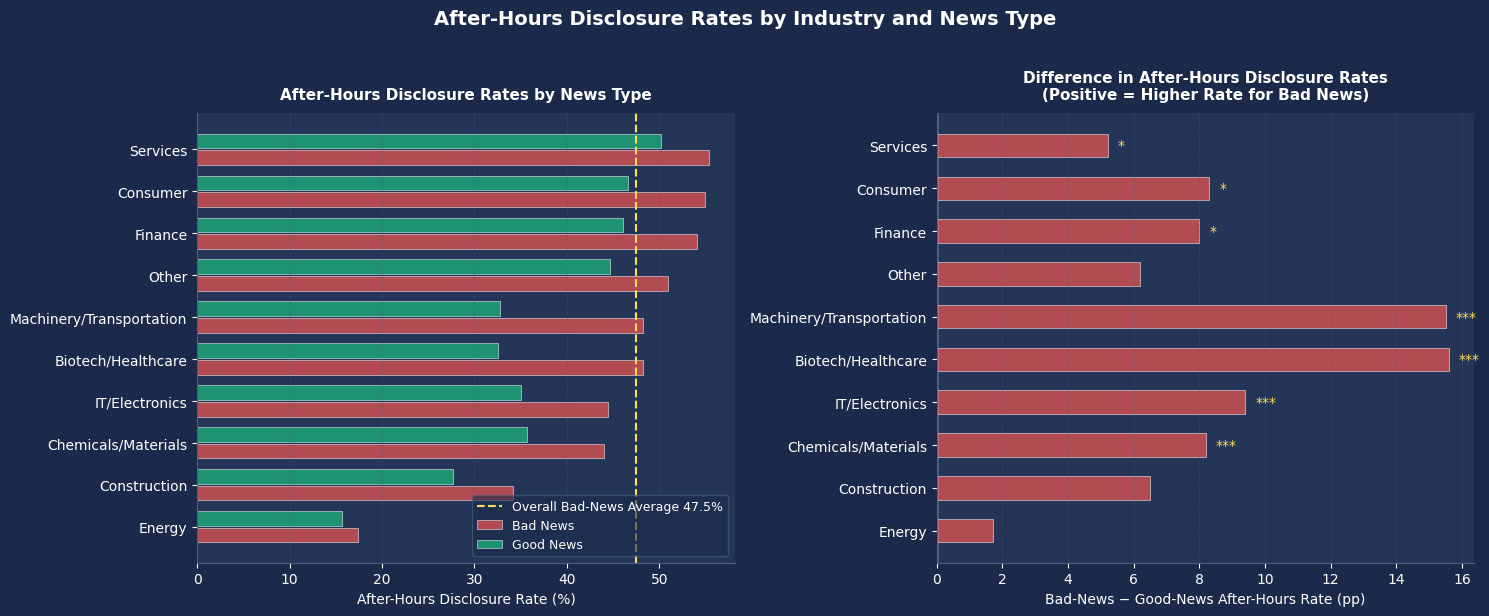

In [11]:
# ================================================================
# CELL 8: Visualize After-Hours Disclosure Rates by Industry
# ================================================================

plot_s = (
    sector_summary
    .dropna(subset=["Difference (pp)"])
    .sort_values(
        "Bad-News After-Hours (%)",
        ascending=True
    )
)

y = np.arange(len(plot_s))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "After-Hours Disclosure Rates by Industry and News Type",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.02,
)

# Panel 1: Bad-news vs good-news after-hours rates
ax = axes[0]
ax.set_facecolor("#243558")

ax.barh(
    y - 0.2,
    plot_s["Bad-News After-Hours (%)"],
    0.35,
    color="#C44E52",
    alpha=0.9,
    label="Bad News",
    edgecolor="white",
    linewidth=0.4,
)

ax.barh(
    y + 0.2,
    plot_s["Good-News After-Hours (%)"],
    0.35,
    color="#1D9E75",
    alpha=0.9,
    label="Good News",
    edgecolor="white",
    linewidth=0.4,
)

ax.axvline(
    total_bad_after_pct,
    color="#FFDD57",
    lw=1.5,
    ls="--",
    label=(
        f"Overall Bad-News Average "
        f"{total_bad_after_pct:.1f}%"
    ),
)

ax.set_yticks(y)
ax.set_yticklabels(
    plot_s["Sector"],
    fontsize=10
)
ax.set_xlabel(
    "After-Hours Disclosure Rate (%)"
)
ax.set_title(
    "After-Hours Disclosure Rates by News Type",
    fontsize=11,
    fontweight="bold",
    pad=10,
)
ax.legend(fontsize=9)
ax.grid(
    axis="x",
    ls="--",
    alpha=0.3
)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")


# Panel 2: Bad-news minus good-news difference
ax = axes[1]
ax.set_facecolor("#243558")

colors = [
    "#C44E52" if d > 0
    else "#4C72B0"
    for d in plot_s["Difference (pp)"]
]

ax.barh(
    y,
    plot_s["Difference (pp)"],
    0.55,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.4,
)

ax.axvline(
    0,
    color="#FFFFFF",
    lw=1.0
)

ax.set_yticks(y)
ax.set_yticklabels(
    plot_s["Sector"],
    fontsize=10
)

ax.set_xlabel(
    "Bad-News − Good-News After-Hours Rate (pp)"
)

ax.set_title(
    "Difference in After-Hours Disclosure Rates\n"
    "(Positive = Higher Rate for Bad News)",
    fontsize=11,
    fontweight="bold",
    pad=10,
)

for i, (d, sig) in enumerate(
    zip(
        plot_s["Difference (pp)"],
        plot_s["Significance"]
    )
):
    if sig:
        ax.text(
            d + 0.3 if d >= 0 else d - 0.3,
            i,
            sig,
            va="center",
            ha="left" if d >= 0 else "right",
            fontsize=10,
            color="#FFDD57",
        )

ax.grid(
    axis="x",
    ls="--",
    alpha=0.3
)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_1_sector_timing.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)

plt.show()


## 13.1. After-Hours Bad-News Disclosure Rates by Industry

After-hours disclosure rates for bad and good news were compared within each industry. The chi-square tests evaluate the association between **news type and disclosure timing** within each industry.

### Main Results

The overall after-hours rate for bad-news disclosures was **47.5%**, but substantial cross-industry variation was observed. Services (55.4%), Consumer (54.9%), and Finance (54.1%) recorded rates above the overall average, whereas Construction (34.2%) and Energy (17.4%) were markedly lower.

The News Type × Disclosure Timing association was statistically significant at the 5% level in **seven industries**: IT/Electronics, Chemicals/Materials, Machinery/Transportation, Finance, Consumer, Biotech/Healthcare, and Services. Four of these industries—IT/Electronics, Chemicals/Materials, Machinery/Transportation, and Biotech/Healthcare—were significant at **p < 0.001**.

Descriptively, the largest bad-news minus good-news differences in after-hours rates included Biotech/Healthcare (+15.6 pp), Machinery/Transportation (+15.5 pp), IT/Electronics (+9.4 pp), and Chemicals/Materials (+8.2 pp).

### Interpretation and Limitation

The results provide evidence that disclosure timing is associated with news type in several industries. However, the chi-square tests do not establish that firms deliberately choose after-hours timing for strategic reasons. The observed differences may also reflect firm-specific reporting practices, operational schedules, or other unobserved factors.

In [13]:
# ================================================================
# CELL 9: Industry-Level Opening Gap Returns and Kruskal-Wallis Test
# ================================================================

bad_after = df_hb[
    (df_hb["news"] == "Bad News")
    & (df_hb["timing"] == "After-hours")
].copy()

bad_after["gap_ret_pct"] = (
    bad_after["gap_ret"] * 100
)

gap_rows = []

for sector in sector_summary["Sector"]:
    sub = (
        bad_after[
            bad_after["sector"] == sector
        ]["gap_ret_pct"]
        .dropna()
    )

    if len(sub) < 5:
        continue

    gap_rows.append({
        "Sector": sector,
        "n": len(sub),
        "Mean (%)": round(
            sub.mean(), 3
        ),
        "Median (%)": round(
            sub.median(), 3
        ),
        "Std. Dev.": round(
            sub.std(), 4
        ),
        "5th Percentile (%)": round(
            sub.quantile(0.05), 3
        ),
    })

gap_summary = (
    pd.DataFrame(gap_rows)
    .sort_values("Mean (%)")
)

print(
    "=== Industry-Level Opening Gap Returns "
    "for After-Hours Bad-News Disclosures ==="
)
print(
    gap_summary.to_string(index=False)
)

groups = [
    bad_after[
        bad_after["sector"] == row["Sector"]
    ]["gap_ret_pct"]
    .dropna()
    .values
    for _, row in gap_summary.iterrows()
    if len(
        bad_after[
            bad_after["sector"] == row["Sector"]
        ]["gap_ret_pct"]
        .dropna()
    ) >= 5
]

if len(groups) >= 2:
    h_stat, p_kw = stats.kruskal(*groups)

    sig_kw = (
        "***" if p_kw < 0.001
        else "**" if p_kw < 0.01
        else "*" if p_kw < 0.05
        else "(Not Significant)"
    )

    print(
        f"\nKruskal-Wallis: "
        f"H={h_stat:.3f}, "
        f"p={p_kw:.4f} "
        f"{sig_kw}"
    )


=== Industry-Level Opening Gap Returns for After-Hours Bad-News Disclosures ===
                  Sector   n  Mean (%)  Median (%)  Std. Dev.  5th Percentile (%)
     Chemicals/Materials 278    -0.956      -0.484     2.6988              -5.400
                  Energy   8    -0.898      -0.532     1.4828              -3.264
          IT/Electronics 462    -0.743      -0.622     3.0036              -5.127
Machinery/Transportation 286    -0.628      -0.397     2.5745              -4.867
                Consumer 234    -0.502      -0.223     1.8244              -3.161
      Biotech/Healthcare 191    -0.436      -0.337     1.9656              -3.971
            Construction  52    -0.256       0.000     1.3575              -2.521
                   Other  57    -0.240       0.000     2.6859              -3.513
                 Finance 237     0.013       0.000     1.6099              -2.001
                Services 108     0.168      -0.057     3.5140              -3.057

Kruskal-Wallis: H

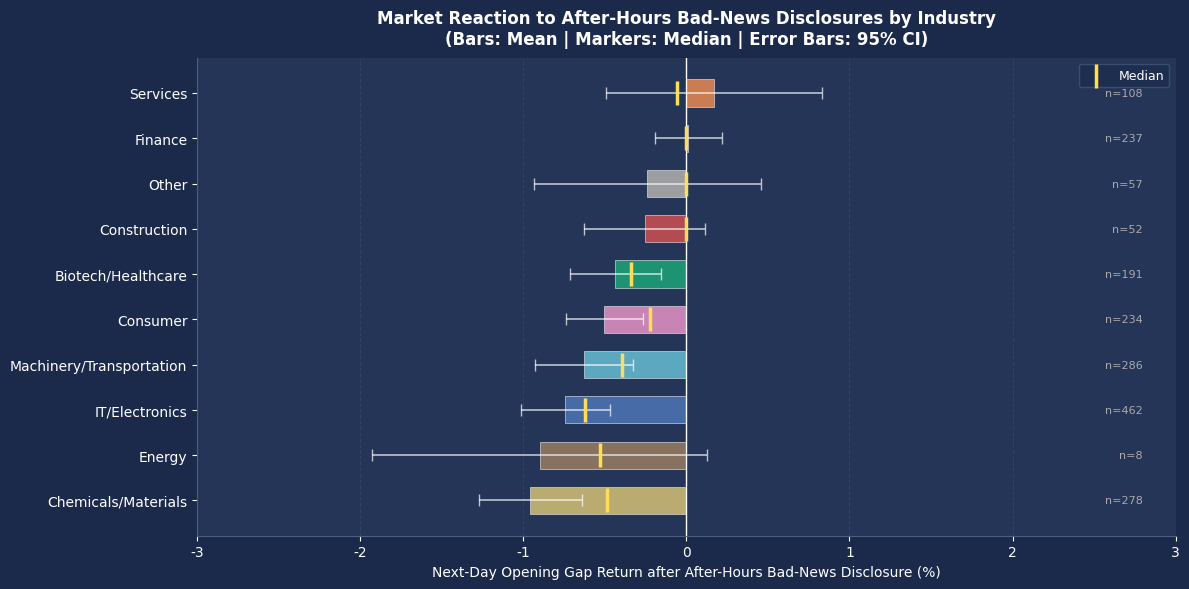

In [14]:
# ================================================================
# CELL 10: Visualize Industry-Level Opening Gap Returns
# ================================================================

y = np.arange(len(gap_summary))

bar_colors = [
    SECTOR_COLORS.get(
        sector,
        "#AAAAAA"
    )
    for sector in gap_summary["Sector"]
]

# Approximate 95% confidence interval for the mean
gap_summary = gap_summary.copy()

gap_summary["SE"] = (
    gap_summary["Std. Dev."]
    / np.sqrt(gap_summary["n"])
)

gap_summary["CI95"] = (
    1.96 * gap_summary["SE"]
)


fig, ax = plt.subplots(
    figsize=(12, 6)
)

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")

bars = ax.barh(
    y,
    gap_summary["Mean (%)"],
    0.6,
    color=bar_colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.4,
)

ax.errorbar(
    gap_summary["Mean (%)"],
    y,
    xerr=gap_summary["CI95"],
    fmt="none",
    color="white",
    capsize=4,
    lw=1.2,
    alpha=0.7,
)

ax.axvline(
    0,
    color="#FFFFFF",
    lw=1.0
)

ax.scatter(
    gap_summary["Median (%)"],
    y,
    marker="|",
    s=300,
    color="#FFDD57",
    zorder=5,
    label="Median",
    linewidths=2.5,
)

ax.set_xlim(-3, 3)

ax.set_yticks(y)
ax.set_yticklabels(
    gap_summary["Sector"],
    fontsize=10
)

ax.set_xlabel(
    "Next-Day Opening Gap Return after "
    "After-Hours Bad-News Disclosure (%)",
    fontsize=10,
)

ax.set_title(
    "Market Reaction to After-Hours Bad-News Disclosures by Industry\n"
    "(Bars: Mean | Markers: Median | Error Bars: 95% CI)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)

ax.legend(fontsize=9)

for bar, n in zip(
    bars,
    gap_summary["n"]
):
    ax.text(
        2.8,
        bar.get_y()
        + bar.get_height() / 2,
        f"n={n}",
        va="center",
        ha="right",
        fontsize=8,
        color="#AAAAAA",
    )

ax.grid(
    axis="x",
    ls="--",
    alpha=0.3
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_2_sector_gap.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)

plt.show()


## 13.2. Industry-Level Market Impact of After-Hours Bad-News Disclosures

For after-hours bad-news disclosures, the opening gap return measures the price change from the disclosure-day close to the next trading-day open. A Kruskal–Wallis test was used to assess whether the distribution of these opening gap returns differed across industries.

### Main Results

The Kruskal–Wallis test indicated a statistically significant difference across industries (**H = 44.133, p < 0.001**).

The most negative average opening gap returns were observed in:

- **Chemicals/Materials: −0.956%**
- **IT/Electronics: −0.743%**
- **Machinery/Transportation: −0.628%**

By contrast, Finance (+0.013%) and Services (+0.168%) showed comparatively limited average opening-gap reactions despite relatively high after-hours disclosure rates.

These results show that the **frequency of after-hours bad-news disclosures and the magnitude of the overnight market reaction need not move together**, motivating a two-dimensional comparison of disclosure frequency and market impact.

Across many industries, the mean opening gap return was lower than the median, which is consistent with negative tail observations affecting the average. Mean–median differences alone, however, are not a formal test of distributional skewness.

### Statistical Limitation

The Kruskal–Wallis test establishes that at least some industry distributions differ in rank. It does not identify which specific pairs of industries differ; pairwise post-hoc tests would be required for that purpose.

Chi-Square Tests: Bad-News Severity × Disclosure Timing by Industry
------------------------------------------------------------------------
Consumer                     chi2=12.60 p=0.0134 *
Machinery/Transportation     chi2=25.23 p=0.0000 ***
IT/Electronics               chi2=7.82 p=0.0982 (Not Significant)
Chemicals/Materials          chi2=20.26 p=0.0004 ***
Finance                      chi2=23.28 p=0.0001 ***
Biotech/Healthcare           chi2=10.28 p=0.0360 *
Services                     chi2=1.04 p=0.9033 (Not Significant)


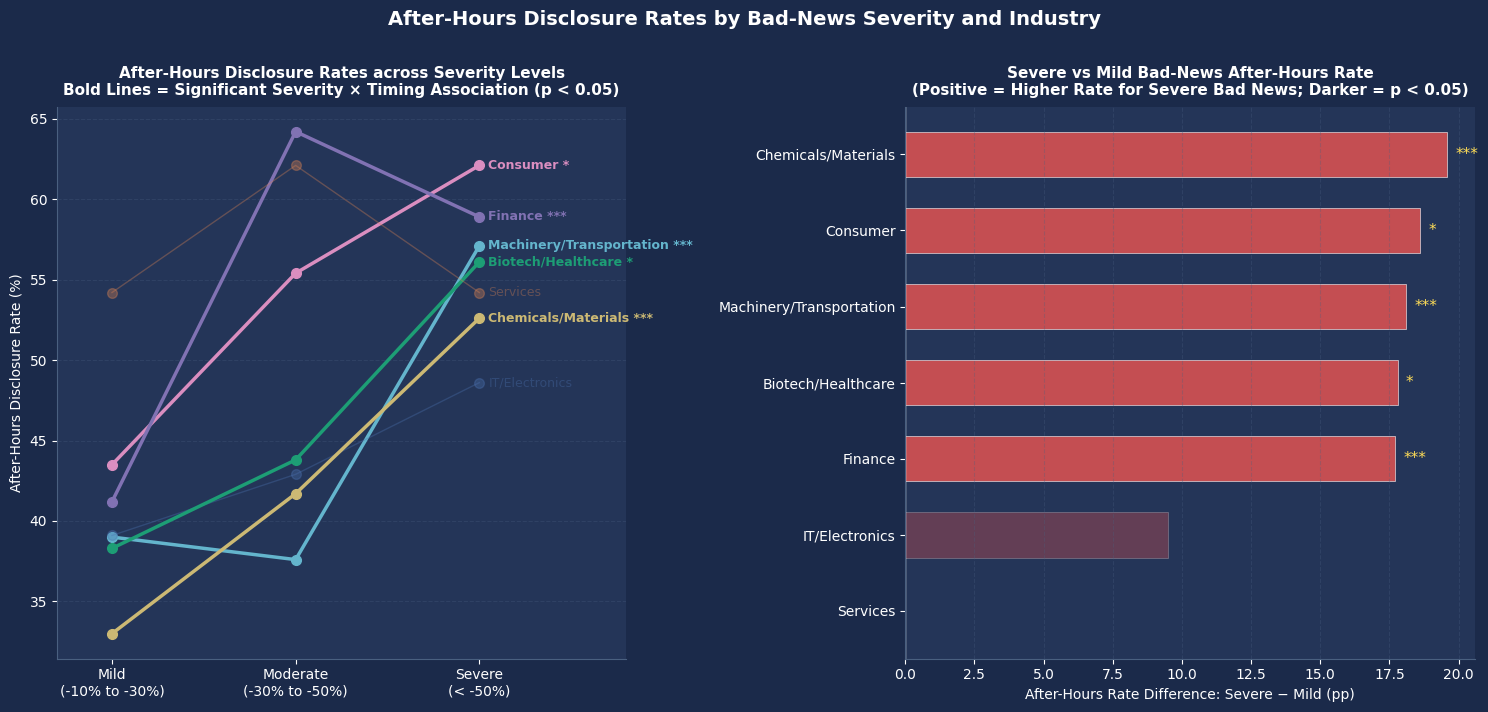

In [15]:
# ================================================================
# CELL 11: Bad-News Severity × Industry Analysis
# ================================================================

from scipy.stats import chi2_contingency

# Define bad-news severity intervals
bins = [
    -np.inf,
    -0.50,
    -0.30,
    -0.10,
]

labels = [
    "Severe (< -50%)",
    "Moderate (-30% to -50%)",
    "Mild (-10% to -30%)",
]

bad_df = df_hb[
    df_hb["news"] == "Bad News"
].copy()

bad_df["severity"] = pd.cut(
    bad_df["oi_chg_pct"],
    bins=bins,
    labels=labels,
)

bad_df = bad_df.dropna(
    subset=["severity"]
)

focus = [
    "Consumer",
    "Machinery/Transportation",
    "IT/Electronics",
    "Chemicals/Materials",
    "Finance",
    "Biotech/Healthcare",
    "Services",
]


sev_rows = []

for sector in focus:
    sub = bad_df[
        bad_df["sector"] == sector
    ]

    if len(sub) < 15:
        continue

    for severity in labels:
        grp = sub[
            sub["severity"] == severity
        ]

        if len(grp) < 5:
            continue

        after_pct = (
            grp["timing"]
            .eq("After-hours")
            .mean()
            * 100
        )

        sev_rows.append({
            "Sector": sector,
            "Severity": severity,
            "n": len(grp),
            "After-Hours (%)": round(
                after_pct, 1
            ),
        })


sev_df = pd.DataFrame(sev_rows)


# ------------------------------------------------------------
# Chi-square tests by industry:
# Bad-News Severity × Disclosure Timing
# ------------------------------------------------------------

print(
    "Chi-Square Tests: "
    "Bad-News Severity × Disclosure Timing by Industry"
)
print("-" * 72)

chi2_pvals = {}

for sector in focus:
    sub = (
        bad_df[
            bad_df["sector"] == sector
        ]
        .dropna(
            subset=["severity"]
        )
    )

    if len(sub) < 15:
        continue

    ct = pd.crosstab(
        sub["severity"],
        sub["timing"]
    )

    for col in [
        "Pre-market",
        "Intraday",
        "After-hours",
    ]:
        if col not in ct.columns:
            ct[col] = 0

    ct = ct[
        [
            "Pre-market",
            "Intraday",
            "After-hours",
        ]
    ]

    try:
        chi2, p, _, _ = chi2_contingency(ct)

        chi2_pvals[sector] = p

        sig = (
            "***" if p < 0.001
            else "**" if p < 0.01
            else "*" if p < 0.05
            else "(Not Significant)"
        )

        print(
            f"{sector:28s} "
            f"chi2={chi2:.2f} "
            f"p={p:.4f} "
            f"{sig}"
        )

    except Exception:
        chi2_pvals[sector] = np.nan


# ------------------------------------------------------------
# Severity profiles
# ------------------------------------------------------------

pivot = sev_df.pivot(
    index="Sector",
    columns="Severity",
    values="After-Hours (%)",
)

pivot = pivot.reindex(
    columns=labels
)

pivot = pivot.reindex(
    [
        sector
        for sector in focus
        if sector in pivot.index
    ]
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7)
)

fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "After-Hours Disclosure Rates by Bad-News Severity and Industry",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.01,
)


# ------------------------------------------------------------
# Panel 1: Mild -> Moderate -> Severe
# ------------------------------------------------------------

ax = axes[0]
ax.set_facecolor("#243558")

x_pos = [0, 1, 2]

x_labels = [
    "Mild\n(-10% to -30%)",
    "Moderate\n(-30% to -50%)",
    "Severe\n(< -50%)",
]

for sector in pivot.index:
    row = pivot.loc[sector]

    vals = [
        row.get(
            "Mild (-10% to -30%)",
            np.nan
        ),
        row.get(
            "Moderate (-30% to -50%)",
            np.nan
        ),
        row.get(
            "Severe (< -50%)",
            np.nan
        ),
    ]

    color = SECTOR_COLORS.get(
        sector,
        "#AAAAAA"
    )

    p = chi2_pvals.get(
        sector,
        1.0
    )

    # Emphasize industries with a significant
    # Severity × Timing association.
    lw = 2.5 if p < 0.05 else 1.0
    alpha = 1.0 if p < 0.05 else 0.35

    ax.plot(
        x_pos,
        vals,
        marker="o",
        lw=lw,
        alpha=alpha,
        color=color,
        markersize=7,
    )

    sig = (
        "***" if p < 0.001
        else "**" if p < 0.01
        else "*" if p < 0.05
        else ""
    )

    label = (
        f"{sector} {sig}"
        if sig
        else sector
    )

    ax.text(
        2.05,
        vals[2],
        label,
        va="center",
        fontsize=9,
        color=color,
        alpha=alpha,
        fontweight=(
            "bold"
            if sig
            else "normal"
        ),
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(
    x_labels,
    fontsize=10
)

ax.set_xlim(-0.3, 2.8)
ax.set_ylabel(
    "After-Hours Disclosure Rate (%)"
)

ax.set_title(
    "After-Hours Disclosure Rates across Severity Levels\n"
    "Bold Lines = Significant Severity × Timing Association (p < 0.05)",
    fontsize=11,
    fontweight="bold",
    pad=8,
)

ax.grid(
    axis="y",
    ls="--",
    alpha=0.3
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")


# ------------------------------------------------------------
# Panel 2: Severe minus Mild difference
# ------------------------------------------------------------

ax = axes[1]
ax.set_facecolor("#243558")

diff_col = (
    pivot["Severe (< -50%)"]
    - pivot["Mild (-10% to -30%)"]
)

diff_df2 = diff_col.reset_index()
diff_df2.columns = [
    "Sector",
    "Difference (pp)",
]

diff_df2["p-value"] = (
    diff_df2["Sector"]
    .map(chi2_pvals)
)

diff_df2["Significance"] = (
    diff_df2["p-value"]
    .apply(
        lambda p:
        "***" if p < 0.001
        else "**" if p < 0.01
        else "*" if p < 0.05
        else ""
    )
)

diff_df2 = diff_df2.sort_values(
    "Difference (pp)",
    ascending=True
)

colors_d = [
    "#C44E52" if value > 0
    else "#4C72B0"
    for value in diff_df2["Difference (pp)"]
]

alphas_d = [
    1.0 if p < 0.05
    else 0.4
    for p in diff_df2["p-value"]
]

y_d = np.arange(
    len(diff_df2)
)

bars = ax.barh(
    y_d,
    diff_df2["Difference (pp)"],
    0.6,
    color=colors_d,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.4,
)

for bar, alpha in zip(
    bars,
    alphas_d
):
    bar.set_alpha(alpha)

ax.axvline(
    0,
    color="#FFFFFF",
    lw=1.0
)

ax.set_yticks(y_d)
ax.set_yticklabels(
    diff_df2["Sector"],
    fontsize=10
)

ax.set_xlabel(
    "After-Hours Rate Difference: Severe − Mild (pp)"
)

ax.set_title(
    "Severe vs Mild Bad-News After-Hours Rate\n"
    "(Positive = Higher Rate for Severe Bad News; "
    "Darker = p < 0.05)",
    fontsize=11,
    fontweight="bold",
    pad=8,
)

for i, (difference, sig) in enumerate(
    zip(
        diff_df2["Difference (pp)"],
        diff_df2["Significance"]
    )
):
    if sig:
        ax.text(
            difference + 0.3
            if difference > 0
            else difference - 0.3,
            i,
            sig,
            va="center",
            ha=(
                "left"
                if difference > 0
                else "right"
            ),
            fontsize=11,
            color="#FFDD57",
        )

ax.grid(
    axis="x",
    ls="--",
    alpha=0.3
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_3_severity_sector.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)

plt.show()


## 13.3. After-Hours Disclosure Rates by Bad-News Severity and Industry

Bad-news observations were divided into three operating-income decline categories: Mild (−10% to −30%), Moderate (−30% to −50%), and Severe (below −50%). Within each industry, the chi-square test evaluates the association between **bad-news severity and disclosure timing**.

### Main Results

Statistically significant Severity × Timing associations were observed in five industries:

- Consumer: **p = 0.013**
- Machinery/Transportation: **p < 0.001**
- Chemicals/Materials: **p < 0.001**
- Finance: **p < 0.001**
- Biotech/Healthcare: **p = 0.036**

Descriptively, the Severe-minus-Mild difference in after-hours rates was approximately **+18.6 pp for Consumer**, **+18.1 pp for Machinery/Transportation**, and **+19.6 pp for Chemicals/Materials**.

IT/Electronics (p = 0.098) and Services (p = 0.903) did not show statistically significant Severity × Timing associations.

### Interpretation

The significant results are consistent with the possibility that disclosure timing varies with the magnitude of negative earnings information in some industries. However, the chi-square tests do not establish deliberate timing behavior or causal intent. The endpoint difference between Severe and Mild groups is also descriptive and should not be interpreted as proof of a monotonic response across all severity levels.

Sector,Number of Firms,Repeated After-Hours Firms,Repeated-Firm Share (%),Mean Bad-News After-Hours Ratio (%)
Services,23,10,43.5%,55.0%
Consumer,45,19,42.2%,56.3%
Finance,49,18,36.7%,52.3%
Biotech/Healthcare,46,15,32.6%,50.8%
IT/Electronics,118,38,32.2%,44.8%
Machinery/Transportation,74,20,27.0%,46.0%
Chemicals/Materials,73,19,26.0%,42.5%


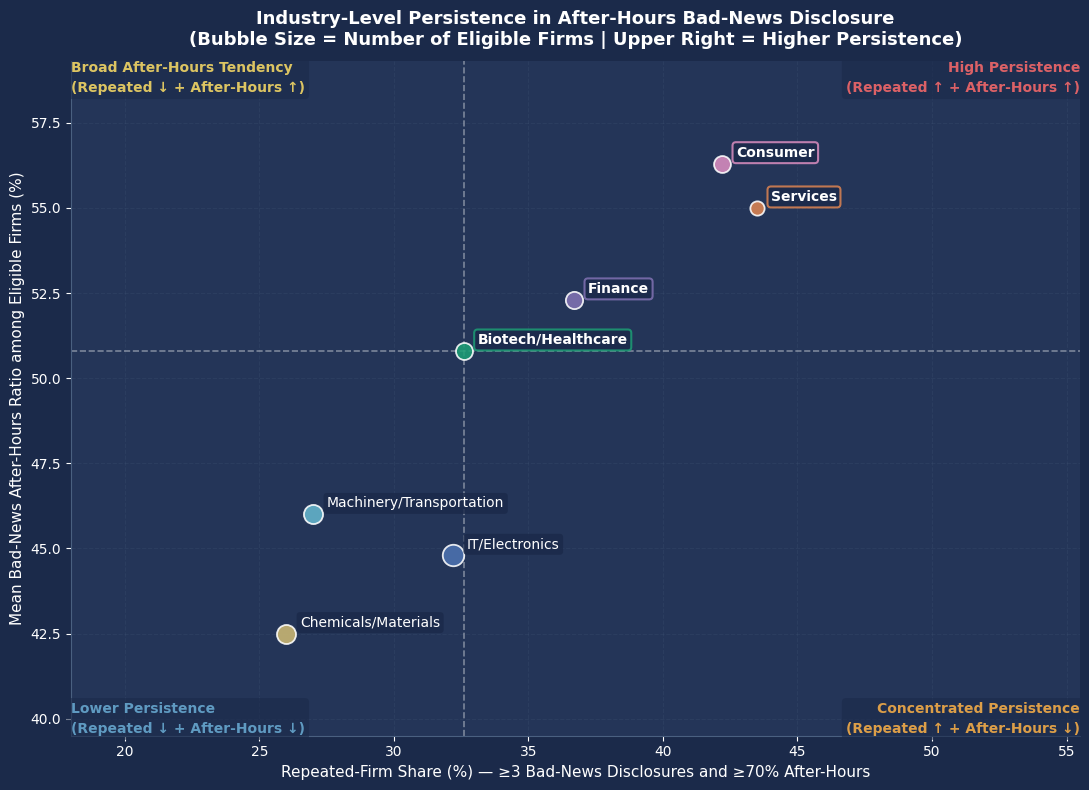

In [16]:
# ================================================================
# CELL 12: Industry-Level Concentration of Repeated After-Hours Firms
# ================================================================

# Repeated-firm criterion:
# at least three bad-news disclosures and
# at least 70% of those disclosures released after hours.
MIN_DISCLOSURES = 3
REPEAT_THRESHOLD = 0.70

bad_df2 = df_hb[
    df_hb["news"] == "Bad News"
].copy()

repeat_rows = []

for sector in focus:
    sub = bad_df2[
        bad_df2["sector"] == sector
    ]

    corp_stats = (
        sub
        .groupby("stock_code")["timing"]
        .agg(
            total="count",
            n_after=lambda x: (
                x == "After-hours"
            ).sum(),
        )
        .reset_index()
    )

    corp_stats["after_ratio"] = (
        corp_stats["n_after"]
        / corp_stats["total"]
    )

    eligible = corp_stats[
        corp_stats["total"]
        >= MIN_DISCLOSURES
    ]

    if len(eligible) == 0:
        continue

    repeat_pct = (
        eligible["after_ratio"]
        .ge(REPEAT_THRESHOLD)
        .mean()
        * 100
    )

    repeat_rows.append({
        "Sector": sector,
        "Number of Firms": len(eligible),
        "Repeated After-Hours Firms": int(
            eligible["after_ratio"]
            .ge(REPEAT_THRESHOLD)
            .sum()
        ),
        "Repeated-Firm Share (%)": round(
            repeat_pct,
            1
        ),
        "Mean Bad-News After-Hours Ratio (%)": round(
            eligible["after_ratio"]
            .mean()
            * 100,
            1
        ),
    })


repeat_df = (
    pd.DataFrame(repeat_rows)
    .sort_values(
        "Repeated-Firm Share (%)",
        ascending=False
    )
)


from IPython.display import display

display(
    repeat_df.style
    .format({
        "Repeated-Firm Share (%)": "{:.1f}%",
        "Mean Bad-News After-Hours Ratio (%)": "{:.1f}%",
    })
    .background_gradient(
        subset=["Repeated-Firm Share (%)"],
        cmap="Reds"
    )
    .set_caption(
        "Industry-Level Concentration of Firms with Repeated "
        "After-Hours Bad-News Disclosures "
        f"(≥ {MIN_DISCLOSURES} Bad-News Disclosures and "
        f"≥ {int(REPEAT_THRESHOLD * 100)}% After-Hours Ratio)"
    )
    .hide(axis="index")
)


# ------------------------------------------------------------
# Scatter plot:
# Repeated-firm share vs mean bad-news after-hours ratio
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 8)
)

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")

x_vals = repeat_df[
    "Repeated-Firm Share (%)"
]

y_vals = repeat_df[
    "Mean Bad-News After-Hours Ratio (%)"
]

x_mid = x_vals.median()
y_mid = y_vals.median()

ax.axvline(
    x_mid,
    color="#FFFFFF",
    lw=1.2,
    ls="--",
    alpha=0.4,
)

ax.axhline(
    y_mid,
    color="#FFFFFF",
    lw=1.2,
    ls="--",
    alpha=0.4,
)

xlim = (
    x_vals.min() - 8,
    x_vals.max() + 12
)

ylim = (
    y_vals.min() - 3,
    y_vals.max() + 3
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)


# Neutral quadrant labels:
# both axes describe disclosure persistence, not causal risk.
quad_cfg = [
    (
        xlim[1],
        ylim[1],
        "High Persistence\n(Repeated ↑ + After-Hours ↑)",
        "#FF6B6B",
        "right",
        "top",
    ),
    (
        xlim[0],
        ylim[1],
        "Broad After-Hours Tendency\n(Repeated ↓ + After-Hours ↑)",
        "#FFE066",
        "left",
        "top",
    ),
    (
        xlim[1],
        ylim[0],
        "Concentrated Persistence\n(Repeated ↑ + After-Hours ↓)",
        "#FFB347",
        "right",
        "bottom",
    ),
    (
        xlim[0],
        ylim[0],
        "Lower Persistence\n(Repeated ↓ + After-Hours ↓)",
        "#6BAED6",
        "left",
        "bottom",
    ),
]

for (
    qx,
    qy,
    ql,
    qc,
    ha,
    va
) in quad_cfg:
    ax.text(
        qx,
        qy,
        ql,
        color=qc,
        fontsize=10,
        fontweight="bold",
        ha=ha,
        va=va,
        alpha=0.85,
        linespacing=1.5,
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#1B2A4A",
            ec="none",
            alpha=0.6,
        ),
    )


# Bubble size = number of eligible firms
for _, row in repeat_df.iterrows():
    sector = row["Sector"]

    x = row[
        "Repeated-Firm Share (%)"
    ]
    y = row[
        "Mean Bad-News After-Hours Ratio (%)"
    ]

    size = (
        np.sqrt(
            row["Number of Firms"]
        )
        * 22
    )

    color = SECTOR_COLORS.get(
        sector,
        "#AAAAAA"
    )

    ax.scatter(
        x,
        y,
        s=size,
        color=color,
        alpha=0.88,
        edgecolors="white",
        linewidths=1.3,
        zorder=3,
    )

    is_high = (
        (x >= x_mid)
        and (y >= y_mid)
    )

    font_weight = (
        "bold"
        if is_high
        else "normal"
    )

    outline = dict(
        boxstyle="round,pad=0.25",
        fc="#1B2A4A",
        ec=(
            color
            if is_high
            else "none"
        ),
        alpha=0.85,
        lw=(
            1.5
            if is_high
            else 0
        ),
    )

    ax.annotate(
        sector,
        (x, y),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=10,
        color="#FFFFFF",
        fontweight=font_weight,
        zorder=4,
        bbox=outline,
    )


ax.set_xlabel(
    "Repeated-Firm Share (%) — "
    "≥3 Bad-News Disclosures and ≥70% After-Hours",
    fontsize=11,
)

ax.set_ylabel(
    "Mean Bad-News After-Hours Ratio among Eligible Firms (%)",
    fontsize=11,
)

ax.set_title(
    "Industry-Level Persistence in After-Hours Bad-News Disclosure\n"
    "(Bubble Size = Number of Eligible Firms | "
    "Upper Right = Higher Persistence)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.grid(
    ls="--",
    alpha=0.2
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_4_repeat_sector.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)

plt.show()


## 13.4. Industry-Level Concentration of Firms with Repeated After-Hours Disclosures

For each industry, firms were classified as exhibiting a repeated after-hours bad-news pattern if they had at least three bad-news disclosures and released at least 70% of them after hours. This analysis evaluates whether elevated industry-level after-hours rates are concentrated among firms that repeatedly meet this threshold.

### Main Results

The highest repeated-firm shares were observed in **Services (43.5%)**, **Consumer (42.2%)**, and **Finance (36.7%)**. Consumer and Services were positioned above the cross-industry medians on both the repeated-firm share and mean bad-news after-hours ratio dimensions.

By contrast, **Machinery/Transportation (27.0%)** and **Chemicals/Materials (26.0%)** had lower repeated-firm concentrations despite statistically significant Severity × Timing associations in the preceding analysis.

### Interpretation

A high repeated-firm share indicates that an industry's aggregate after-hours pattern is relatively concentrated among firms that repeatedly satisfy the specified threshold. A lower share does **not** prove that the pattern is structurally distributed across the entire industry; it only indicates that the industry result is less dominated by firms meeting this particular repeated-disclosure criterion.

The 70% threshold and minimum-disclosure requirement are researcher-defined and should therefore be treated as descriptive screening rules rather than causal evidence of strategic behavior.

Sector,n,Mean (%),Median (%),10th Percentile (%),5th Percentile (%),Below -3% (%),Below -5% (%)
Chemicals/Materials,278,-0.956%,-0.484%,-3.567%,-5.400%,15.1%,5.8%
IT/Electronics,462,-0.743%,-0.622%,-3.564%,-5.127%,14.3%,5.6%
Machinery/Transportation,286,-0.628%,-0.397%,-3.805%,-4.867%,12.9%,4.5%
Consumer,234,-0.502%,-0.223%,-2.494%,-3.161%,5.6%,2.1%
Biotech/Healthcare,191,-0.436%,-0.337%,-2.479%,-3.971%,8.9%,1.6%
Finance,237,0.013%,0.000%,-1.460%,-2.001%,2.1%,1.3%
Services,108,0.168%,-0.057%,-2.402%,-3.057%,5.6%,0.9%


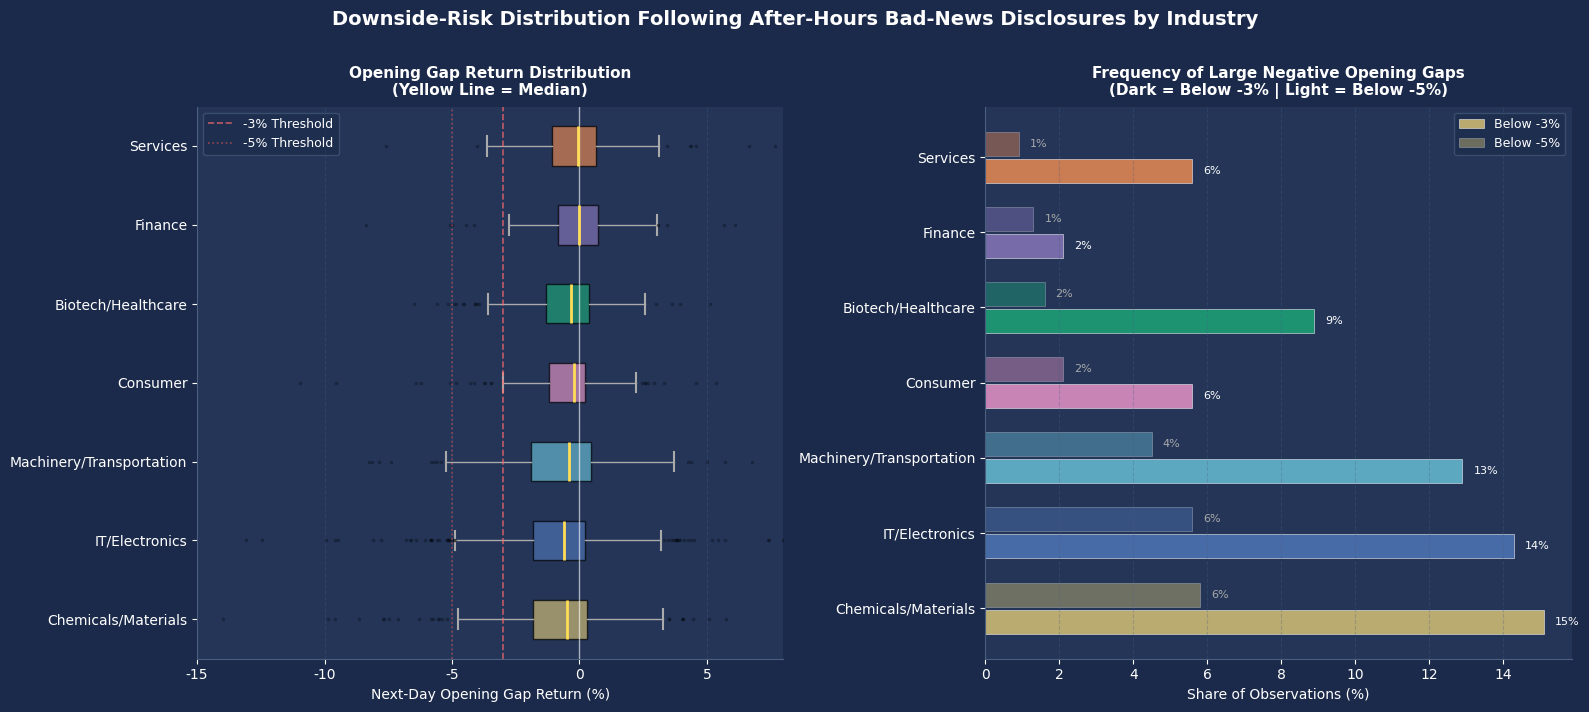

In [17]:
# ================================================================
# CELL 13: Downside-Risk Distribution after After-Hours Bad News
# ================================================================

focus_all = [
    "Consumer",
    "Machinery/Transportation",
    "IT/Electronics",
    "Chemicals/Materials",
    "Finance",
    "Biotech/Healthcare",
    "Services",
]

bad_after = df_hb[
    (df_hb["news"] == "Bad News")
    & (df_hb["timing"] == "After-hours")
].copy()

bad_after["gap_pct"] = (
    bad_after["gap_ret"] * 100
)


# ------------------------------------------------------------
# Calculate industry-level downside-risk metrics
# ------------------------------------------------------------

risk_rows = []

for sector in focus_all:
    sub = (
        bad_after[
            bad_after["sector"] == sector
        ]["gap_pct"]
        .dropna()
    )

    if len(sub) < 10:
        continue

    risk_rows.append({
        "Sector": sector,
        "n": len(sub),
        "Mean (%)": round(
            sub.mean(),
            3
        ),
        "Median (%)": round(
            sub.median(),
            3
        ),
        "10th Percentile (%)": round(
            sub.quantile(0.10),
            3
        ),
        "5th Percentile (%)": round(
            sub.quantile(0.05),
            3
        ),
        "Below -3% (%)": round(
            (sub < -3).mean() * 100,
            1
        ),
        "Below -5% (%)": round(
            (sub < -5).mean() * 100,
            1
        ),
    })


risk_df = (
    pd.DataFrame(risk_rows)
    .sort_values("Mean (%)")
)


from IPython.display import display

display(
    risk_df.style
    .format({
        "Mean (%)": "{:.3f}%",
        "Median (%)": "{:.3f}%",
        "10th Percentile (%)": "{:.3f}%",
        "5th Percentile (%)": "{:.3f}%",
        "Below -3% (%)": "{:.1f}%",
        "Below -5% (%)": "{:.1f}%",
    })
    .background_gradient(
        subset=["Below -3% (%)"],
        cmap="Reds"
    )
    .background_gradient(
        subset=["5th Percentile (%)"],
        cmap="Blues_r"
    )
    .set_caption(
        "Industry-Level Downside-Risk Distribution "
        "Following After-Hours Bad-News Disclosures"
    )
    .hide(axis="index")
)


# ------------------------------------------------------------
# Visualization: boxplots and threshold frequencies
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "Downside-Risk Distribution Following "
    "After-Hours Bad-News Disclosures by Industry",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.01,
)


# Panel 1: Opening-gap return distributions
ax = axes[0]
ax.set_facecolor("#243558")

plot_data = []
plot_labels = []
plot_colors = []

for _, row in risk_df.iterrows():
    sector = row["Sector"]

    sub = (
        bad_after[
            bad_after["sector"] == sector
        ]["gap_pct"]
        .dropna()
    )

    plot_data.append(
        sub.values
    )
    plot_labels.append(
        sector
    )
    plot_colors.append(
        SECTOR_COLORS.get(
            sector,
            "#AAAAAA"
        )
    )

bp = ax.boxplot(
    plot_data,
    vert=False,
    patch_artist=True,
    widths=0.5,
    showfliers=True,
    flierprops=dict(
        marker=".",
        markersize=3,
        alpha=0.3,
    ),
    medianprops=dict(
        color="#FFDD57",
        lw=2
    ),
    whiskerprops=dict(
        color="#AAAAAA",
        lw=1
    ),
    capprops=dict(
        color="#AAAAAA",
        lw=1.5
    ),
)

for patch, color in zip(
    bp["boxes"],
    plot_colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yticklabels(
    plot_labels,
    fontsize=10
)

ax.axvline(
    0,
    color="#FFFFFF",
    lw=1.0,
    alpha=0.6,
)

ax.axvline(
    -3,
    color="#FF6B6B",
    lw=1.2,
    ls="--",
    alpha=0.7,
    label="-3% Threshold",
)

ax.axvline(
    -5,
    color="#C44E52",
    lw=1.2,
    ls=":",
    alpha=0.7,
    label="-5% Threshold",
)

ax.set_xlabel(
    "Next-Day Opening Gap Return (%)"
)

ax.set_title(
    "Opening Gap Return Distribution\n"
    "(Yellow Line = Median)",
    fontsize=11,
    fontweight="bold",
    pad=8,
)

ax.legend(fontsize=9)

ax.set_xlim(-15, 8)

ax.grid(
    axis="x",
    ls="--",
    alpha=0.3
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")


# Panel 2: Frequency below researcher-defined thresholds
ax = axes[1]
ax.set_facecolor("#243558")

y_r = np.arange(
    len(risk_df)
)

colors_r = [
    SECTOR_COLORS.get(
        sector,
        "#AAAAAA"
    )
    for sector in risk_df["Sector"]
]

ax.barh(
    y_r - 0.18,
    risk_df["Below -3% (%)"],
    0.32,
    color=colors_r,
    alpha=0.9,
    edgecolor="white",
    lw=0.4,
    label="Below -3%",
)

ax.barh(
    y_r + 0.18,
    risk_df["Below -5% (%)"],
    0.32,
    color=colors_r,
    alpha=0.45,
    edgecolor="white",
    lw=0.4,
    label="Below -5%",
)

ax.set_yticks(y_r)

ax.set_yticklabels(
    risk_df["Sector"],
    fontsize=10
)

ax.set_xlabel(
    "Share of Observations (%)"
)

ax.set_title(
    "Frequency of Large Negative Opening Gaps\n"
    "(Dark = Below -3% | Light = Below -5%)",
    fontsize=11,
    fontweight="bold",
    pad=8,
)

ax.legend(fontsize=9)

ax.grid(
    axis="x",
    ls="--",
    alpha=0.3
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")


for i, (v3, v5) in enumerate(
    zip(
        risk_df["Below -3% (%)"],
        risk_df["Below -5% (%)"]
    )
):
    ax.text(
        v3 + 0.3,
        i - 0.18,
        f"{v3:.0f}%",
        va="center",
        fontsize=8,
        color="#FFFFFF",
    )

    ax.text(
        v5 + 0.3,
        i + 0.18,
        f"{v5:.0f}%",
        va="center",
        fontsize=8,
        color="#AAAAAA",
    )


plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_5_downside_risk.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)

plt.show()


## 13.5. Industry-Level Downside-Risk Distribution Following After-Hours Bad-News Disclosures

This section measures the frequency of large negative next-day opening gaps after after-hours bad-news disclosures. The −3% and −5% cutoffs are researcher-defined analytical thresholds rather than estimated regulatory or economic breakpoints.

### Main Results

The highest frequencies of opening gaps below −3% were observed in:

- **Chemicals/Materials: 15.1%** below −3%; **5.8%** below −5%
- **IT/Electronics: 14.3%** below −3%; **5.6%** below −5%
- **Machinery/Transportation: 12.9%** below −3%; **4.5%** below −5%

Thus, in these industries, approximately one in every seven to eight after-hours bad-news disclosures was followed by an opening gap decline exceeding 3%.

Finance (2.1% below −3%) and Services (5.6% below −3%) showed much lower frequencies of large negative overnight moves despite relatively high after-hours disclosure rates.

### Interpretation

The findings reinforce the distinction between **how often bad news is released after hours** and **how strongly prices move by the next opening**. Chemicals/Materials, IT/Electronics, and Machinery/Transportation combine relatively negative average opening gaps with comparatively frequent large negative overnight moves.

The analysis does not observe when investors acquired information, whether they had an opportunity to trade, or whether losses were actually realized. Accordingly, the results should be interpreted as market-reaction measures rather than direct evidence of investor harm.

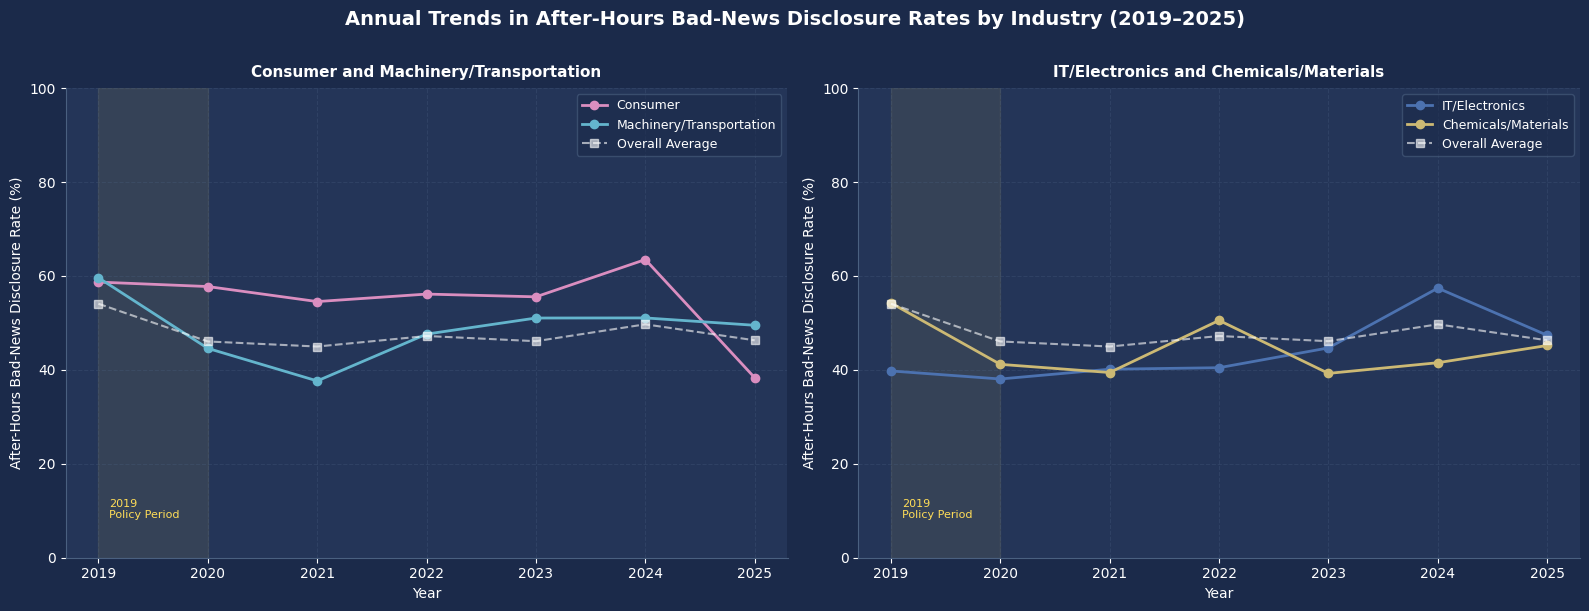


Annual After-Hours Bad-News Disclosure Rates (%)
Consumer                    : {2019: 58.7, 2020: 57.7, 2021: 54.5, 2022: 56.1, 2023: 55.6, 2024: 63.5, 2025: 38.3}
Machinery/Transportation    : {2019: 59.6, 2020: 44.6, 2021: 37.6, 2022: 47.6, 2023: 51.0, 2024: 51.1, 2025: 49.5}
IT/Electronics              : {2019: 39.8, 2020: 38.1, 2021: 40.1, 2022: 40.5, 2023: 44.7, 2024: 57.4, 2025: 47.4}
Chemicals/Materials         : {2019: 54.2, 2020: 41.2, 2021: 39.4, 2022: 50.5, 2023: 39.3, 2024: 41.5, 2025: 45.2}
Overall Average             : {2019: 54.1, 2020: 46.1, 2021: 45.0, 2022: 47.2, 2023: 46.1, 2024: 49.7, 2025: 46.3}


In [18]:
# ================================================================
# CELL 14: Annual Trends in After-Hours Bad-News Disclosure Rates
# ================================================================

focus_sectors = [
    "Consumer",
    "Machinery/Transportation",
    "IT/Electronics",
    "Chemicals/Materials",
]

bad_yr = df_hb[
    (df_hb["news"] == "Bad News")
    & df_hb["year"].between(
        2019,
        2025
    )
].copy()


total_trend = (
    bad_yr
    .groupby("year")["timing"]
    .apply(
        lambda x:
        (x == "After-hours").mean() * 100
    )
    .reset_index(
        name="After-Hours Rate (%)"
    )
)


sector_trend = {}

for sector in focus_sectors:
    sub = bad_yr[
        bad_yr["sector"] == sector
    ]

    trend = (
        sub
        .groupby("year")["timing"]
        .apply(
            lambda x:
            (x == "After-hours").mean() * 100
        )
        .reset_index(
            name="After-Hours Rate (%)"
        )
    )

    sector_trend[sector] = trend


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "Annual Trends in After-Hours Bad-News Disclosure Rates "
    "by Industry (2019–2025)",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.01,
)


for ax_idx, (
    sectors,
    title
) in enumerate([
    (
        [
            "Consumer",
            "Machinery/Transportation",
        ],
        "Consumer and Machinery/Transportation",
    ),
    (
        [
            "IT/Electronics",
            "Chemicals/Materials",
        ],
        "IT/Electronics and Chemicals/Materials",
    ),
]):
    ax = axes[ax_idx]
    ax.set_facecolor("#243558")

    for sector in sectors:
        trend = sector_trend[sector]

        ax.plot(
            trend["year"],
            trend["After-Hours Rate (%)"],
            marker="o",
            lw=2,
            label=sector,
            color=SECTOR_COLORS.get(
                sector,
                "#AAAAAA"
            ),
        )

    ax.plot(
        total_trend["year"],
        total_trend["After-Hours Rate (%)"],
        marker="s",
        lw=1.5,
        ls="--",
        color="#FFFFFF",
        alpha=0.6,
        label="Overall Average",
    )

    # Contextual marker only. This chart does not estimate a causal
    # effect of any policy introduced around 2019.
    ax.axvspan(
        2019,
        2020,
        alpha=0.08,
        color="#FFDD57",
    )

    ax.text(
        2019.1,
        8,
        "2019\nPolicy Period",
        color="#FFDD57",
        fontsize=8,
        va="bottom",
    )

    ax.set_title(
        title,
        fontsize=11,
        fontweight="bold",
        pad=8,
    )

    ax.set_ylabel(
        "After-Hours Bad-News Disclosure Rate (%)"
    )

    ax.set_xlabel("Year")

    # Full percentage scale for comparability
    ax.set_ylim(0, 100)

    ax.set_xticks(
        range(2019, 2026)
    )

    ax.legend(fontsize=9)

    ax.grid(
        ls="--",
        alpha=0.3
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#4A6080")


plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_6_sector_trend.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)

plt.show()


# ------------------------------------------------------------
# Print annual values
# ------------------------------------------------------------

print(
    "\nAnnual After-Hours Bad-News Disclosure Rates (%)"
)

for sector in focus_sectors:
    trend = (
        sector_trend[sector]
        .set_index("year")[
            "After-Hours Rate (%)"
        ]
        .round(1)
    )

    print(
        f"{sector:28s}: "
        f"{trend.to_dict()}"
    )

overall_trend = (
    total_trend
    .set_index("year")[
        "After-Hours Rate (%)"
    ]
    .round(1)
)

print(
    f"{'Overall Average':28s}: "
    f"{overall_trend.to_dict()}"
)


## 13.6. Annual Trends in After-Hours Bad-News Disclosure Rates (2019–2025)

Annual after-hours bad-news disclosure rates were compared for Consumer, Machinery/Transportation, IT/Electronics, and Chemicals/Materials, together with the overall sample average.

### Main Results

The overall rate was **54.1% in 2019** and subsequently remained broadly around the **45%–50% range**. Consumer reached **63.5% in 2024**, while the other focus industries displayed year-to-year fluctuations without a common monotonic trend.

The time series therefore provides descriptive evidence that industry-level differences persisted throughout the 2019–2025 sample period.

### Interpretation and Limitation

The shaded 2019–2020 period is included only as contextual information. Because the sample begins in 2019 and does not provide a substantial pre-policy comparison period, the analysis cannot identify the causal effect or effectiveness of any regulatory intervention introduced around that time.

Annual sample sizes also differ across industries, so individual-year estimates may be volatile. The figure should be interpreted primarily as a descriptive view of post-2019 temporal patterns rather than as a policy-effect evaluation.

In [19]:
# ================================================================
# CELL 15: Prepare Variables for the Integrated Industry Matrix
# ================================================================

matrix = (
    sector_summary[
        [
            "Sector",
            "Bad-News Disclosures",
            "Bad-News After-Hours (%)",
        ]
    ]
    .merge(
        gap_summary[
            [
                "Sector",
                "Mean (%)",
            ]
        ]
        .rename(
            columns={
                "Mean (%)":
                "Mean Opening Gap Return (%)"
            }
        ),
        on="Sector",
        how="inner",
    )
)

x_mid = (
    matrix[
        "Bad-News After-Hours (%)"
    ]
    .median()
)

y_mid = (
    matrix[
        "Mean Opening Gap Return (%)"
    ]
    .median()
)

print(
    "Cross-Industry Median Reference Values — "
    f"After-Hours Rate: {x_mid:.1f}% | "
    f"Mean Opening Gap Return: {y_mid:.3f}%"
)

print()

print(
    matrix[
        [
            "Sector",
            "Bad-News After-Hours (%)",
            "Mean Opening Gap Return (%)",
            "Bad-News Disclosures",
        ]
    ]
    .sort_values(
        "Bad-News After-Hours (%)",
        ascending=False
    )
    .to_string(index=False)
)


Cross-Industry Median Reference Values — After-Hours Rate: 48.2% | Mean Opening Gap Return: -0.469%

                  Sector  Bad-News After-Hours (%)  Mean Opening Gap Return (%)  Bad-News Disclosures
                Services                      55.4                        0.168                   195
                Consumer                      54.9                       -0.502                   426
                 Finance                      54.1                        0.013                   440
                   Other                      50.9                       -0.240                   112
      Biotech/Healthcare                      48.2                       -0.436                   396
Machinery/Transportation                      48.2                       -0.628                   593
          IT/Electronics                      44.5                       -0.743                  1039
     Chemicals/Materials                      44.0                       -0.956    

In [20]:
# ================================================================
# CELL 16: Integrated Industry Matrix Classification
# ================================================================

grade_rows = []

for _, row in (
    matrix
    .sort_values(
        "Bad-News After-Hours (%)",
        ascending=False
    )
    .iterrows()
):
    x = row[
        "Bad-News After-Hours (%)"
    ]

    y = row[
        "Mean Opening Gap Return (%)"
    ]

    # "High impact" means a more negative mean opening gap return
    # relative to the cross-industry median.
    if (
        x >= x_mid
        and y <= y_mid
    ):
        grade = (
            "Q1  High Frequency / High Impact"
        )

    elif (
        x < x_mid
        and y <= y_mid
    ):
        grade = (
            "Q2  Lower Frequency / High Impact"
        )

    elif (
        x >= x_mid
        and y > y_mid
    ):
        grade = (
            "Q3  High Frequency / Lower Impact"
        )

    else:
        grade = (
            "Q4  Lower Frequency / Lower Impact"
        )

    grade_rows.append({
        "Sector": row["Sector"],
        "Bad-News After-Hours (%)": round(
            x,
            1
        ),
        "Mean Opening Gap Return (%)": round(
            y,
            3
        ),
        "Bad-News Disclosures": int(
            row["Bad-News Disclosures"]
        ),
        "Matrix Group": grade,
    })


grade_df = pd.DataFrame(
    grade_rows
)


def color_grade(value):
    if "Q1" in str(value):
        return (
            "background-color: #FDECEA; "
            "color: #C0392B; "
            "font-weight: bold"
        )

    if "Q2" in str(value):
        return (
            "background-color: #FEF3E2; "
            "color: #D35400; "
            "font-weight: bold"
        )

    if "Q3" in str(value):
        return (
            "background-color: #FEF9E7; "
            "color: #B7950B; "
            "font-weight: bold"
        )

    if "Q4" in str(value):
        return (
            "background-color: #EAF4FB; "
            "color: #1A5276; "
            "font-weight: bold"
        )

    return ""


from IPython.display import display

display(
    grade_df.style
    .format({
        "Bad-News After-Hours (%)": "{:.1f}%",
        "Mean Opening Gap Return (%)": "{:.3f}%",
        "Bad-News Disclosures": "{:,}",
    })
    .map(
        color_grade,
        subset=["Matrix Group"]
    )
    .background_gradient(
        subset=["Bad-News After-Hours (%)"],
        cmap="Reds"
    )
    .background_gradient(
        subset=["Mean Opening Gap Return (%)"],
        cmap="Blues_r"
    )
    .set_caption(
        "Integrated Industry Risk Matrix Classification"
    )
    .hide(axis="index")
)


Sector,Bad-News After-Hours (%),Mean Opening Gap Return (%),Bad-News Disclosures,Matrix Group
Services,55.4%,0.168%,195,Q3 High Frequency / Lower Impact
Consumer,54.9%,-0.502%,426,Q1 High Frequency / High Impact
Finance,54.1%,0.013%,440,Q3 High Frequency / Lower Impact
Other,50.9%,-0.240%,112,Q3 High Frequency / Lower Impact
Biotech/Healthcare,48.2%,-0.436%,396,Q3 High Frequency / Lower Impact
Machinery/Transportation,48.2%,-0.628%,593,Q1 High Frequency / High Impact
IT/Electronics,44.5%,-0.743%,"1,039",Q2 Lower Frequency / High Impact
Chemicals/Materials,44.0%,-0.956%,637,Q2 Lower Frequency / High Impact
Construction,34.2%,-0.256%,152,Q4 Lower Frequency / Lower Impact
Energy,17.4%,-0.898%,46,Q2 Lower Frequency / High Impact


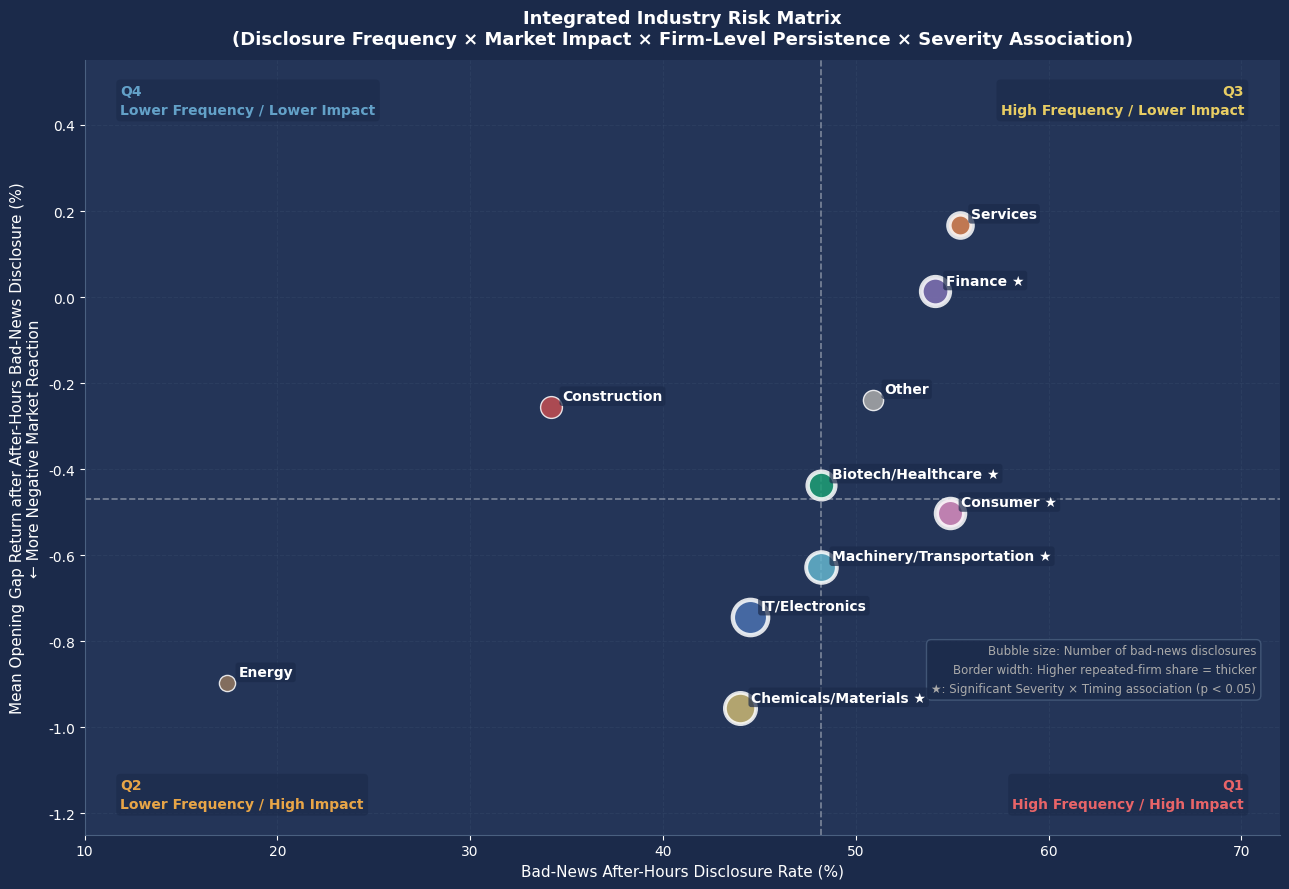

In [21]:
# ================================================================
# CELL 17: Integrated Industry Risk Matrix
#
# X-axis: after-hours bad-news disclosure rate
# Y-axis: mean opening gap return
# Bubble size: number of bad-news disclosures
# Border width: repeated-firm share
# Star: significant Severity × Timing association
# ================================================================

repeat_map = (
    repeat_df
    .set_index("Sector")[
        "Repeated-Firm Share (%)"
    ]
    .to_dict()
)

sig_severity = {
    sector
    for sector in chi2_pvals
    if chi2_pvals[sector] < 0.05
}


fig, ax = plt.subplots(
    figsize=(13, 9)
)

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")

x_mid = (
    matrix[
        "Bad-News After-Hours (%)"
    ]
    .median()
)

y_mid = (
    matrix[
        "Mean Opening Gap Return (%)"
    ]
    .median()
)


ax.axvline(
    x_mid,
    color="#FFFFFF",
    lw=1.2,
    ls="--",
    alpha=0.4,
)

ax.axhline(
    y_mid,
    color="#FFFFFF",
    lw=1.2,
    ls="--",
    alpha=0.4,
)

ax.set_xlim(10, 72)
ax.set_ylim(-1.25, 0.55)


# Neutral quadrant labels
for (
    qx,
    qy,
    label,
    color,
    ha,
    va,
) in [
    (
        0.97,
        0.03,
        "Q1\nHigh Frequency / High Impact",
        "#FF6B6B",
        "right",
        "bottom",
    ),
    (
        0.03,
        0.03,
        "Q2\nLower Frequency / High Impact",
        "#FFB347",
        "left",
        "bottom",
    ),
    (
        0.97,
        0.97,
        "Q3\nHigh Frequency / Lower Impact",
        "#FFE066",
        "right",
        "top",
    ),
    (
        0.03,
        0.97,
        "Q4\nLower Frequency / Lower Impact",
        "#6BAED6",
        "left",
        "top",
    ),
]:
    ax.text(
        qx,
        qy,
        label,
        color=color,
        fontsize=10,
        fontweight="bold",
        ha=ha,
        va=va,
        alpha=0.9,
        linespacing=1.5,
        transform=ax.transAxes,
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#1B2A4A",
            ec="none",
            alpha=0.6,
        ),
    )


# ------------------------------------------------------------
# Plot industry bubbles
# ------------------------------------------------------------

for _, row in matrix.iterrows():
    sector = row["Sector"]

    x = row[
        "Bad-News After-Hours (%)"
    ]

    y = row[
        "Mean Opening Gap Return (%)"
    ]

    size = (
        np.sqrt(
            row["Bad-News Disclosures"]
        )
        * 20
    )

    color = SECTOR_COLORS.get(
        sector,
        "#AAAAAA"
    )

    repeat_value = repeat_map.get(
        sector,
        0
    )

    line_width = (
        1
        + repeat_value / 15
    )

    ax.scatter(
        x,
        y,
        s=size,
        color=color,
        alpha=0.85,
        edgecolors="white",
        linewidths=line_width,
        zorder=3,
    )

    star = (
        " ★"
        if sector in sig_severity
        else ""
    )

    ax.annotate(
        f"{sector}{star}",
        (x, y),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=10,
        color="#FFFFFF",
        fontweight="bold",
        zorder=4,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="#1B2A4A",
            ec="none",
            alpha=0.7,
        ),
    )


legend_text = (
    "Bubble size: Number of bad-news disclosures\n"
    "Border width: Higher repeated-firm share = thicker\n"
    "★: Significant Severity × Timing association (p < 0.05)"
)

ax.text(
    0.98,
    0.18,
    legend_text,
    transform=ax.transAxes,
    fontsize=8.5,
    color="#AAAAAA",
    va="bottom",
    ha="right",
    linespacing=1.6,
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="#1B2A4A",
        ec="#4A6080",
        alpha=0.8,
    ),
)

ax.set_xlabel(
    "Bad-News After-Hours Disclosure Rate (%)",
    fontsize=11,
)

ax.set_ylabel(
    "Mean Opening Gap Return after "
    "After-Hours Bad-News Disclosure (%)\n"
    "← More Negative Market Reaction",
    fontsize=11,
)

ax.set_title(
    "Integrated Industry Risk Matrix\n"
    "(Disclosure Frequency × Market Impact × "
    "Firm-Level Persistence × Severity Association)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.grid(
    ls="--",
    alpha=0.2
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_7_integrated_risk_matrix.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)

plt.show()


## 13.7. Integrated Industry Risk Matrix

The preceding analyses are combined into an exploratory two-dimensional industry matrix. The x-axis represents the after-hours bad-news disclosure rate, while the y-axis represents the mean next-day opening gap return following after-hours bad-news disclosure. Bubble size indicates the number of bad-news disclosures, border width reflects the repeated-firm share, and ★ marks industries with a statistically significant Severity × Timing association.

### Matrix Classification

**Q1 — High Frequency / High Impact: Consumer★, Machinery/Transportation★**

These industries are above the cross-industry median in after-hours bad-news disclosure frequency and have more negative average opening-gap returns than the median reference. Consumer also has a relatively high repeated-firm concentration. Machinery/Transportation has a lower repeated-firm share, indicating that its classification is less concentrated among firms meeting the repeated-disclosure threshold; this does not by itself establish an industry-wide structural mechanism.

**Q2 — Lower Frequency / High Impact: IT/Electronics, Chemicals/Materials★, Energy**

These industries are characterized primarily by relatively negative opening-gap reactions rather than unusually high after-hours bad-news disclosure frequency. Chemicals/Materials also exhibits a statistically significant Severity × Timing association. Energy should be interpreted cautiously because its bad-news sample is relatively small.

**Q3 — High Frequency / Lower Impact: Services, Finance★, Biotech/Healthcare★**

These industries have comparatively high after-hours bad-news disclosure rates but less negative average opening-gap reactions. Biotech/Healthcare is relatively close to the matrix boundary and therefore should not be treated as qualitatively distinct from neighboring groups.

**Q4 — Lower Frequency / Lower Impact: Construction**

Construction is below the cross-industry median on both dimensions. This is a relative classification and should not be interpreted as evidence that the industry is free of disclosure-related risk.

### Interpretation

The matrix is designed to distinguish **disclosure frequency** from **market-reaction magnitude**. These dimensions need not move together and therefore provide complementary information for exploratory industry screening.

The **Other** category represents firms whose KSIC divisions were not included in the nine predefined research sectors. It is therefore treated as a residual classification rather than as a substantive industry sector and is not included in the substantive quadrant interpretation above.

The classification is median-based and descriptive. It does not establish strategic intent, causal mechanisms, or the effectiveness of any particular regulatory intervention. Results are also sensitive to the cross-industry median reference points and to the limited sample sizes of some industries.

# Industry-Level Analysis: Summary of Results

---

## 1. Analysis Overview

This analysis examines **8,553 earnings disclosures from Korean listed firms between 2019 and 2025** to evaluate whether after-hours bad-news disclosure patterns differ across industries. Firms are classified using KSIC codes obtained from the DART Company Overview API. **KSIC codes were successfully retrieved for all firms, and 97.5% were mapped to one of the nine predefined research sectors; the remaining firms were retained in a residual “Other” category.**

The analysis combines five components: industry-level disclosure-timing comparisons, opening-gap market reactions, severity-based timing patterns, concentration of repeated after-hours firms, and downside-risk distributions integrated into a two-dimensional industry matrix.

---

## 2. Key Findings

### 2.1. After-Hours Bad-News Disclosure Rates

The overall after-hours rate for bad-news disclosures was **47.5%**. Services (55.4%), Consumer (54.9%), and Finance (54.1%) recorded relatively high rates, whereas Construction (34.2%) and Energy (17.4%) were substantially lower.

Within-industry News Type × Disclosure Timing chi-square tests were significant at **p < 0.05 in seven industries**: IT/Electronics, Chemicals/Materials, Machinery/Transportation, Finance, Consumer, Biotech/Healthcare, and Services. Four of these—IT/Electronics, Chemicals/Materials, Machinery/Transportation, and Biotech/Healthcare—were significant at **p < 0.001**.

### 2.2. Industry-Level Opening-Gap Market Reaction

The distribution of opening gap returns following after-hours bad-news disclosures differed significantly across industries (**Kruskal–Wallis H = 44.133, p < 0.001**).

The most negative average opening-gap returns were observed in Chemicals/Materials (−0.956%), IT/Electronics (−0.743%), and Machinery/Transportation (−0.628%). Services and Finance showed relatively limited average opening-gap reactions despite high after-hours disclosure rates.

### 2.3. Bad-News Severity and Disclosure Timing

Significant Severity × Timing associations were found in Consumer, Machinery/Transportation, Chemicals/Materials, Finance, and Biotech/Healthcare. Descriptively, severe bad-news observations had after-hours rates roughly 18–20 percentage points higher than mild bad-news observations in Consumer, Machinery/Transportation, and Chemicals/Materials.

These associations are consistent with selective variation in disclosure timing by news magnitude, but they do not establish intentional strategic timing.

### 2.4. Concentration of Repeated After-Hours Firms

Services (43.5%) and Consumer (42.2%) had the highest shares of firms meeting the repeated after-hours criterion. Machinery/Transportation (27.0%) and Chemicals/Materials (26.0%) had lower repeated-firm concentrations despite significant severity associations.

A lower repeated-firm share should not be interpreted as proof of an industry-wide structural pattern; it only indicates that the aggregate result is less concentrated among firms satisfying the chosen threshold.

### 2.5. Downside-Risk Distribution

Chemicals/Materials (15.1%), IT/Electronics (14.3%), and Machinery/Transportation (12.9%) recorded the highest frequencies of opening gap returns below −3% following after-hours bad-news disclosures. The corresponding below −5% frequencies were 5.8%, 5.6%, and 4.5%, respectively.

These results quantify large negative overnight market reactions but do not directly measure realized investor losses or investors' ability to respond.

### 2.6. Integrated Industry Matrix

| Matrix Group | Industries | Relative Characteristics |
|---|---|---|
| Q1: High Frequency / High Impact | Consumer★, Machinery/Transportation★ | Higher after-hours frequency + more negative opening-gap reaction |
| Q2: Lower Frequency / High Impact | IT/Electronics, Chemicals/Materials★, Energy | Lower relative frequency + more negative opening-gap reaction |
| Q3: High Frequency / Lower Impact | Services, Finance★, Biotech/Healthcare★ | Higher relative frequency + less negative opening-gap reaction |
| Q4: Lower Frequency / Lower Impact | Construction | Lower relative frequency + less negative opening-gap reaction |

★ Significant Bad-News Severity × Disclosure Timing association at p < 0.05.

The **Other** category is a residual classification containing firms whose KSIC divisions were not included in the nine predefined research sectors. It is therefore not interpreted as a substantive industry sector in the matrix classification above.

---

## 3. Limitations

First, the matrix uses cross-industry medians and researcher-defined thresholds, so the resulting groups are exploratory rather than absolute risk categories.

Second, the Energy sector contains only 46 bad-news observations, limiting the stability and generalizability of its estimates.

Third, the opening-gap measure captures short-horizon market reaction and does not represent longer-term price adjustment.

Fourth, industry-specific chi-square tests are reported using **unadjusted p-values**. Because multiple hypothesis tests were conducted across industries, marginally significant results should be interpreted cautiously in light of potential multiple-testing effects.

Fifth, the analysis does not control for all potentially relevant firm-level factors, including earnings surprises relative to market expectations, corporate governance characteristics, or institutional ownership. Future work could incorporate these variables in a multivariate industry-level framework.

Finally, the analysis is observational. Statistical associations in disclosure timing should not be interpreted as proof of strategic intent or as causal evidence about regulatory effectiveness.


# Exploratory Policy Framework Based on Industry-Level Analysis

---

## Policy-Design Principle

The integrated industry matrix can serve as an **exploratory screening framework** for considering whether monitoring priorities may differ across industries. The empirical analysis identifies variation in disclosure frequency, short-horizon market reactions, severity associations, and firm-level persistence; it does **not** establish strategic intent or demonstrate that any specific regulatory intervention would be effective.

Accordingly, the options below should be interpreted as potential directions for further policy consideration rather than direct regulatory recommendations. Any implementation would require separate legal review, institutional assessment, and causal evaluation.

---

## Q1: High Frequency / High Impact

### Industries: Consumer, Machinery/Transportation

These industries combine relatively high after-hours bad-news disclosure rates with comparatively negative opening-gap reactions.

Potential monitoring options include:

- enhanced monitoring of repeated after-hours bad-news disclosure patterns;
- advance notification of scheduled earnings-disclosure windows where feasible;
- automated screening for firms with persistent timing patterns;
- targeted review of disclosures followed by unusually large overnight market reactions.

Because the analysis does not establish deliberate strategic timing, hard timing restrictions or sanctions should not be inferred directly from these results.

---

## Q2: Lower Frequency / High Impact

### Industries: IT/Electronics, Chemicals/Materials, Energy

These industries are distinguished more by the magnitude of short-horizon market reactions than by unusually high after-hours disclosure frequency.

Potential monitoring options include:

- clearer disclosure of the drivers of material earnings deterioration;
- industry-specific guidance on explanatory disclosure content;
- post-disclosure review of observations associated with unusually large opening-gap reactions;
- periodic assessment of whether disclosure completeness is associated with subsequent market adjustment.

Market impact alone does not demonstrate deficient disclosure quality. Any review framework would therefore require additional firm- and event-level evidence. Results for Energy should also be interpreted cautiously because of its relatively small bad-news sample.

---

## Q3: High Frequency / Lower Impact

### Industries: Services, Finance, Biotech/Healthcare

These industries exhibit relatively high after-hours bad-news disclosure rates but less negative average opening-gap reactions.

Potential monitoring options include:

- transparency indicators summarizing disclosure-timing patterns;
- issuer education and disclosure-practice guidance;
- periodic monitoring of firms with persistent after-hours patterns;
- voluntary disclosure-quality initiatives or incentive-based programs.

These industries should not be characterized as engaging in strategic disclosure solely on the basis of their relatively high after-hours disclosure frequency.

---

## Q4: Lower Frequency / Lower Impact

### Industry: Construction

Construction is below the cross-industry median on both matrix dimensions.

A proportionate approach would be to maintain routine monitoring while periodically reassessing the industry's relative position as additional observations accumulate. The Q4 classification is comparative and does not imply an absence of disclosure-related risk.

---

## Illustrative Evaluation Roadmap

| Stage | Objective |
|---|---|
| 1 | Establish industry-specific monitoring indicators and validate data quality |
| 2 | Pilot enhanced disclosure review in selected high-impact industries |
| 3 | Evaluate whether monitoring or guidance changes disclosure quality or market outcomes |
| 4 | Re-estimate industry classifications and revise the framework based on observed evidence |

---

## Interpretation and Limitations

The proposed framework is based on **descriptive and associational evidence rather than causal estimates**. Industry classifications depend on cross-industry median reference points, and some industry-specific statistical results are based on unadjusted p-values from multiple hypothesis tests. Marginally significant associations should therefore be interpreted cautiously.

The **Other** category is not included in the substantive policy framework because it represents a residual classification of firms whose KSIC divisions were not assigned to one of the nine predefined research sectors.

The framework should therefore be viewed as a structured way to translate empirical findings into hypotheses for further monitoring and evaluation, rather than as evidence that particular industries require specific regulatory interventions.

---

## Potential Contribution

A differentiated framework may help regulators or exchanges consider how monitoring resources could be allocated across distinct empirical dimensions rather than relying on a single industry-wide indicator. However, any operational policy would require independent evaluation of legal feasibility, compliance costs, unintended consequences, and measurable effects on disclosure quality and market outcomes.